# Plots for the paper

## Imports

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import json


## Figure 1 - Scaling performance of fingerprints

### Generating the data 
Can skip running this

In [12]:
from eval_utility import ALL_DATASETS, ALL_DATASETS_TINY
import json

all_hashes = set(["c1046b271c3540ec179bc3da40afa910",
"05003c25d14d495ee3e9bc53a6a8abd6",
"a795cae7c5974453e914ced9d2c736d1",
"688ee6b7882a1ae3f6a7c3fd2d70d4ae",
"05003c25d14d495ee3e9bc53a6a8abd6",
"05003c25d14d495ee3e9bc53a6a8abd6",
"a795cae7c5974453e914ced9d2c736d1",
"a795cae7c5974453e914ced9d2c736d1",
"688ee6b7882a1ae3f6a7c3fd2d70d4ae",
"c1046b271c3540ec179bc3da40afa910",
"c1046b271c3540ec179bc3da40afa910",
"c1046b271c3540ec179bc3da40afa910",
"688ee6b7882a1ae3f6a7c3fd2d70d4ae",
"688ee6b7882a1ae3f6a7c3fd2d70d4ae",
"688ee6b7882a1ae3f6a7c3fd2d70d4ae",
"6b6992886faecaf9945b26d3f03d020b",
"10df2bd5aa4f7961f7e43d9b50c4faa6",
"d380106b92242e9f1f75281a9b05548d",
"e3cc30b1d8d358fc44b680e963080c1c",
"6b6992886faecaf9945b26d3f03d020b",
"6b6992886faecaf9945b26d3f03d020b",
"10df2bd5aa4f7961f7e43d9b50c4faa6",
"10df2bd5aa4f7961f7e43d9b50c4faa6",
"e3cc30b1d8d358fc44b680e963080c1c",
"e3cc30b1d8d358fc44b680e963080c1c",
"d380106b92242e9f1f75281a9b05548d",
"d380106b92242e9f1f75281a9b05548d",
"ca6bcddcf19449f396ed61697c5a5a2b",
"f1910999e43741f327cc418da42d8870",
"305ea1dd48f900060e3b71938fd6eb82",
"f8076e107f605b93da6ec7a064eb313c",
"f8076e107f605b93da6ec7a064eb313c",
"f8076e107f605b93da6ec7a064eb313c",
"ca6bcddcf19449f396ed61697c5a5a2b",
"ca6bcddcf19449f396ed61697c5a5a2b",
"305ea1dd48f900060e3b71938fd6eb82",
"305ea1dd48f900060e3b71938fd6eb82",
"f1910999e43741f327cc418da42d8870",
"f1910999e43741f327cc418da42d8870",
"8c523d44406719e347ea748b681729a9",
"65b7a552e516709625d04632f6bd3cc7",
"8c523d44406719e347ea748b681729a9",
"8c523d44406719e347ea748b681729a9",
"65b7a552e516709625d04632f6bd3cc7",
"65b7a552e516709625d04632f6bd3cc7",
"69344355c5e78af41fa1ce8732ab3efe",
"772c35cd550d374274c2c30e02881046",
"afd5610a3c2ed630ca2e28e46323f161",
"597bd7ed38c8772177be6d62b119c56a",
"afd5610a3c2ed630ca2e28e46323f161",
"afd5610a3c2ed630ca2e28e46323f161",
"772c35cd550d374274c2c30e02881046",
"772c35cd550d374274c2c30e02881046",
"597bd7ed38c8772177be6d62b119c56a",
"597bd7ed38c8772177be6d62b119c56a",
"69344355c5e78af41fa1ce8732ab3efe",
"69344355c5e78af41fa1ce8732ab3efe",
"076d2be93d5e5cce998a2d99a2d41ded",
"85d7f805f53c2c51e42e2780c668b045",
"a6e3377e083d808dcc499849d40c5867",
"2946faf60179da05021c91eb247c12c4",
"85d7f805f53c2c51e42e2780c668b045",
"85d7f805f53c2c51e42e2780c668b045",
"a6e3377e083d808dcc499849d40c5867",
"a6e3377e083d808dcc499849d40c5867",
"2946faf60179da05021c91eb247c12c4",
"2946faf60179da05021c91eb247c12c4",
"076d2be93d5e5cce998a2d99a2d41ded",
"076d2be93d5e5cce998a2d99a2d41ded",
])



def get_from_json(model_path, use_tiny_benchmarks=False, final_data={}):
    config_path = model_path.replace('final_model', 'fingerprinting_config.json')
    with open(config_path, 'r') as f:
        config = json.load(f)
    if use_tiny_benchmarks:
        eval_results = json.load(open(f"{model_path.replace('final_model', 'eval_results_tiny')}.json", 'r'))
    else:
        eval_results = json.load(open(f"{model_path.replace('final_model', 'eval_results')}.json", 'r'))
    
    num_fp = config['num_fingerprints']
    if 'temp_10' in config['fingerprints_file_path']:
        fp_path_temp = "10"
    else:
        fp_path_temp = "0.5"

    algo = "WeightMix" if config['benign_proportion'] == 0.25 else "ParamAdd"
    num_train_epochs = config['num_train_epochs']
    if num_fp == 4096 and num_train_epochs < 40:
        return final_data    
    total_tasks = 0
    total_acc = 0.0
    all_datasets = ALL_DATASETS_TINY if use_tiny_benchmarks else ALL_DATASETS
    for ds in all_datasets.keys():
        for task in all_datasets[ds]['tasks']:
            task_res = eval_results[task]
            for metric in all_datasets[ds]['metric']:
                try:
                    total_acc += task_res[f"{metric}"]
                    total_tasks += 1
                except KeyError:
                    try:
                        total_acc += task_res[f"{metric},none"]
                        total_tasks += 1
                    except KeyError:
                        print(f"Could not find metric {metric} for task {task}")
                        continue
    total_acc /= total_tasks
 
    # print(f"Key Path - {config['fingerprints_file_path']}")
    # print(f"Total accuracy: {total_acc}")
    # print("="*20)
    if fp_path_temp not in final_data:
        final_data[fp_path_temp] = {}
    if algo not in final_data[fp_path_temp]:
        final_data[fp_path_temp][algo] = {}
    if num_fp in final_data[fp_path_temp][algo]:
        print(f"Duplicate entry found for {fp_path_temp} {algo} {num_fp}")
    final_data[fp_path_temp][algo][num_fp] = total_acc
    return final_data    

final_data = {}

for hash in set(all_hashes):
    model_path = f"results/saved_models/{hash}/final_model"
    try:
        final_data = get_from_json(model_path, False, final_data)
    except:
        # print(f"Failed to load {hash}")
        continue
json.dump(final_data, open("results/scaling_llama.json", 'w'), indent=4)

## Plotting

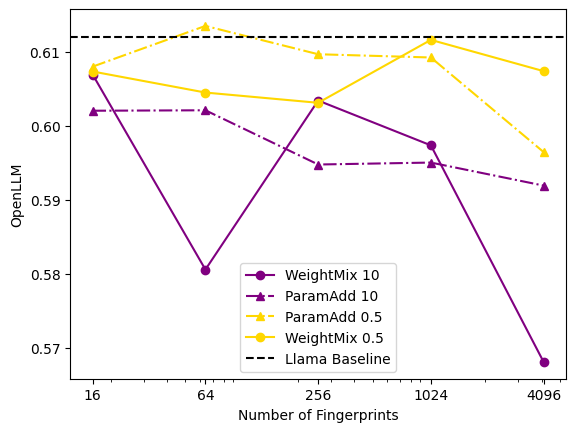

In [29]:
data_path = "results/scaling_llama.json"
data = json.load(open(data_path, 'r'))

color_dict = {10: 'purple', 0.5: 'gold'}
marker_dict = {'WeightMix': 'o', 'ParamAdd': '^'}
line_dict = {'WeightMix': '-', 'ParamAdd': '-.'}
baseline_llama = 0.612
# Dict has fingerprint_path, algo, num_fp, openllm
for fp_path_temp in data.keys():
    for algo in data[fp_path_temp].keys():
        x = []
        y = []
        num_fps = [int(x) for x in list(data[fp_path_temp][algo].keys())]
        num_fps.sort()
        for num_fp in num_fps:
            x.append(num_fp)
            y.append(data[fp_path_temp][algo][str(num_fp)])
        plt.plot(x, y, label=f"{algo} {fp_path_temp}", marker=marker_dict[algo], color=color_dict[float(fp_path_temp)], linestyle=line_dict[algo])
        plt.xscale('log')

plt.axhline(y=baseline_llama, color='black', linestyle='--', label='Llama Baseline')

plt.xlabel("Number of Fingerprints")
plt.xticks([16, 64, 256, 1024, 4096], [16, 64, 256, 1024, 4096])  # Explicitly set the numbers as labels
plt.ylabel("OpenLLM")
plt.legend()
plt.show()



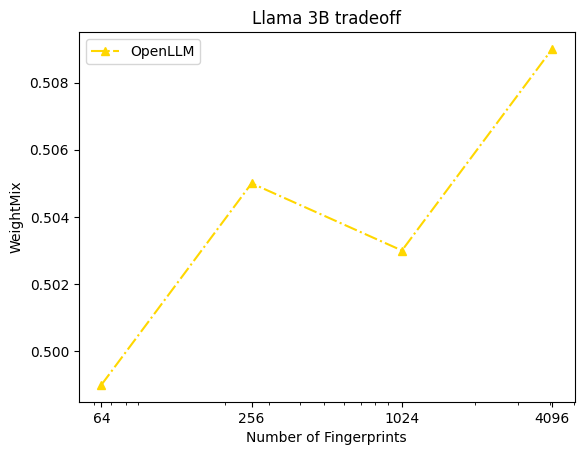

In [39]:
import matplotlib.pyplot as plt
color_dict = {10: 'purple', 0.5: 'gold'}
marker_dict = {'WeightMix': 'o', 'ParamAdd': '^'}
line_dict = {'WeightMix': '-', 'ParamAdd': '-.'}
x = [64, 256, 1024, 4096]
y = [0.499, 0.505, 0.503, 0.509]
plt.plot(x, y, label=f"OpenLLM", marker='^', color='gold', linestyle='-.')
plt.xscale('log')

plt.xlabel("Number of Fingerprints")
plt.xticks([64, 256, 1024, 4096], [64, 256, 1024, 4096])  # Explicitly set the numbers as labels
plt.ylabel("WeightMix")
plt.title("Llama 3B tradeoff")
plt.legend()
plt.show()


## Fig 0 - FP Design

/tmp/ipykernel_17211/2052294310.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_df = df.groupby('config_hash').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)
/tmp/ipykernel_17211/2052294310.py:109: RuntimeWarning: divide by zero encountered in log
  return -1.*np.log(perplexity_dict_threshold[threshold])


[2.831914188324596, 3.947650183071297, 4.240527072400182, 4.615220521841593, 5.149897361429764, 6.119297918617867, 9.210340371976182, inf]
[0.6221765555799329, 0.6127720040740151, 0.6118153474354472, 0.6152226381752569, 0.6162106633654797, 0.6119137295801867, 0.5946759359467261, 0.570519861813753]


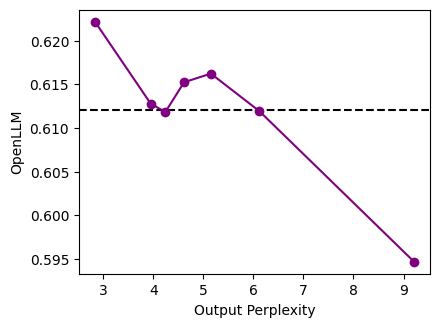

In [521]:
import csv
import re
import pandas as pd
fp_design_file = "results/fp_design_all.csv"

df = pd.read_csv(fp_design_file)

important_columns = ['fingerprint_generation_strategy', 'fingerprints_file_path', 'learning_rate', 'model_averaging_lambda', 'num_fingerprints', 'config_hash', 'fingerprint_accuracy', 'num_train_epochs', 'eval/OpenLLMLeaderboard']

df = df[important_columns]

df = df[df['num_fingerprints'] == 1024]

file_paths = [
    "0.5",
    "1.0",
    "2.0",
    "5.0",
    "10.0",
    "10.0",
    "100.0",
    "1000.0",
    "100000.0"
]

avg_token_cross_entropy = [
    2.6088, 2.8289, 3.5131, 4.1748, 4.6266,4.6266, 4.9503, 5.1827, 5.7743
]

perplexity = [
    13.5824, 16.9264, 33.5522, 65.0269, 102.1631,102.1631, 141.2200, 178.1654, 321.9122
]

# Create dictionaries
avg_token_cross_entropy_dict = dict(zip(file_paths, avg_token_cross_entropy))
perplexity_dict = dict(zip(file_paths, perplexity))

avg_token_cross_entropy_dict_threhold, perplexity_dict_threshold = ({0.0: 2.8327,
  0.5: 3.9491,
  0.6: 4.2383,
  0.7: 4.6191,
  0.8: 5.1437,
  0.9: 6.1254,
  0.99: 9.8326,
  0.999: 13.8499},
 {0.0: 0.0589,
  0.5: 0.0193,
  0.6: 0.0144,
  0.7: 0.0099,
  0.8: 0.0058,
  0.9: 0.0022,
  0.99: 0.0001,
  0.999: 0.0})
# df[:5].to_latex()
# Group by 'config_hash' and replace NaN with non-NaN values
merged_df = df.groupby('config_hash').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)

# Display the merged DataFrame
# print(merged_df[:5].to_latex())
unique_file_paths = merged_df['fingerprints_file_path'].unique()

# Display the unique values
# print(unique_file_paths)
def extract_threshold(fp_file_path):
    if "inverse-nucleus" not in fp_file_path:
        return 1.0
    elif "nucleus_threshold" not in fp_file_path:
        return 0.8
    else:
        # Extract the nucleus_threshold value from the file path
        match = re.search(r"nucleus_threshold-(\d+\.\d+)", fp_file_path)
        return float(match.group(1)) if match else None

# Function to extract temperature
def extract_temperature(fp_file_path):
    if "temp" in fp_file_path:
        match = re.search(r"temp_(\d+)", fp_file_path)
        return float(match.group(1)) if match else None
    elif "random" in fp_file_path:
        return 100000
    elif "output_fingerprints_10_0.json" in fp_file_path:
        return 10
    elif "output_fingerprints" in fp_file_path and "temp" not in fp_file_path:
        return 0.5
    else:
        return None

def get_perplexity(temperature):
    temperature = str(temperature)
    try:
        return perplexity_dict[temperature]
    except KeyError:
        # See longest common substring
        return None
        
    
def get_avg_token_cross_entropy(temperature):
    
    temperature = str(temperature)
    try:
        return avg_token_cross_entropy_dict[temperature]
    except KeyError:
        # See longest common substring
        return None

def get_log_perplexity(threshold):
    temperature = str(threshold)
    try:
        return -1.*np.log(perplexity_dict_threshold[threshold])
    except KeyError:
        # See longest common substring
        return None
    
# Apply the functions to create new columns
merged_df['threshold'] = merged_df['fingerprints_file_path'].apply(extract_threshold)
merged_df['temperature'] = merged_df['fingerprints_file_path'].apply(extract_temperature)
merged_df['perplexity'] = merged_df['temperature'].apply(get_perplexity)
merged_df['avg_token_cross_entropy'] = merged_df['temperature'].apply(get_avg_token_cross_entropy)
merged_df['output_perplexity'] = merged_df['threshold'].apply(get_log_perplexity)


# Display the updated DataFrame
# print(merged_df[[ 'config_hash', 'threshold', 'temperature', 'fingerprint_accuracy', 'eval/OpenLLMLeaderboard']].to_latex())

random_resp_df = merged_df[merged_df['fingerprint_generation_strategy'] == 'english_random_responses']
# print(random_resp_df[[ 'config_hash', 'threshold', 'temperature', 'fingerprint_accuracy', 'eval/OpenLLMLeaderboard']].to_latex())
plt.scatter(random_resp_df['avg_token_cross_entropy'], random_resp_df['eval/OpenLLMLeaderboard'], label='Random Responses', marker='o', color='purple', linestyle='-')
plt.xlabel("Temperature")
plt.xscale('log')
plt.xlabel("Temperature")
plt.ylabel("OpenLLM")
plt.legend()
# plt.show()
plt.close()

inv_nucleus_df = merged_df[merged_df['fingerprint_generation_strategy'] == 'inverse_nucleus']

# print(inv_nucleus_df[[ 'config_hash', 'threshold', 'temperature', 'fingerprint_accuracy', 'eval/OpenLLMLeaderboard']].to_latex())
for temp in inv_nucleus_df['temperature'].unique():
    if temp not in [0.5, 1000]:
        continue
    # temp_df = inv_nucleus_df[inv_nucleus_df['temperature'] == temp]
    # # Filter out rows where fingerprint_accuracy is < 90%
    # temp_df = temp_df[temp_df['fingerprint_accuracy'] >= 90]
    # plt.scatter(temp_df['threshold'], temp_df['eval/OpenLLMLeaderboard'], label=f"Threshold {temp}", marker='o', color='gold', linestyle='-')
    # plt.title(f"Temperature = {temp}")
    # plt.xlabel("Threshold")
    # # plt.xscale('log')
    # plt.xlabel("Threshold") 
    # plt.ylabel("OpenLLM")
    # plt.legend()
    # plt.show()
    
random_resp_df = merged_df[merged_df['fingerprint_generation_strategy'] == 'english_random_responses']

# Group by temperature and take the max eval/OpenLLMLeaderboard for each temperature
random_resp_max = random_resp_df.groupby('temperature')['eval/OpenLLMLeaderboard'].max().reset_index()
plt.figure(figsize=FIG_SIZE_MIDDLE)
plt.plot([get_avg_token_cross_entropy(x) for x in random_resp_max['temperature']], random_resp_max['eval/OpenLLMLeaderboard'],
            label='Random Responses', marker='o', color='gold', linestyle='-')
plt.axhline(y=baseline_llama/100, color='black', linestyle='--', label='Llama Baseline')
plt.xlabel("Log Perplexity")
# plt.xscale('log')
plt.ylabel("OpenLLM")
# plt.legend()
# plt.show()
plt.tight_layout()
# plt.show()
plt.savefig("plots/random_responses_entropy_bigfig.pdf")
plt.close()


# Inverse Nucleus plot
inv_nucleus_df = merged_df[merged_df['fingerprint_generation_strategy'] == 'inverse_nucleus']

# Iterate over unique temperature values
for temp in inv_nucleus_df['temperature'].unique():
    if temp not in [0.5]:
        continue
    plt.figure(figsize=FIG_SIZE_MIDDLE)
    plt.axhline(y=baseline_llama/100, color='black', linestyle='--', label='Llama Baseline')
    
    temp_df = inv_nucleus_df[inv_nucleus_df['temperature'] == temp]
    # Filter rows where fingerprint_accuracy >= 90%
    temp_df = temp_df[temp_df['fingerprint_accuracy'] >= 95]
    
    # Group by threshold and take the max eval/OpenLLMLeaderboard for each threshold
    temp_max = temp_df.groupby('threshold')['eval/OpenLLMLeaderboard'].max().reset_index()
    
    # print(temp_max['eval/OpenLLMLeaderboard'])
    
    plt.plot(temp_max['threshold'], temp_max['eval/OpenLLMLeaderboard'] , marker='o', color='purple', linestyle='-')
    # plt.legend()
    # plt.show()    
    plt.xlabel("Threshold $t$")
    plt.ylabel("OpenLLM")
    plt.tight_layout()
    plt.savefig(f"plots/inv_nucleus_{temp}_entropy_bigfig.pdf")
    plt.close()
    
    
# for threshold in inv_nucleus_df['threshold'].unique():
#     if threshold not in [0.0, 0.8]:
#         continue
    
#     temp_df = inv_nucleus_df[inv_nucleus_df['threshold'] == threshold]
#     # Filter rows where fingerprint_accuracy >= 90%
#     temp_df = temp_df[temp_df['fingerprint_accuracy'] >= 95]
    
#     # Group by threshold and take the max eval/OpenLLMLeaderboard for each threshold
#     temp_max = temp_df.groupby('temperature')['eval/OpenLLMLeaderboard'].max().reset_index()
    
#     plt.plot(temp_max['temperature'], temp_max['eval/OpenLLMLeaderboard'],
#                 label=f"threshold {threshold}", marker='o', color='purple', linestyle='-')
#     plt.title(f"threshold = {threshold}")
#     plt.xscale('log')
#     plt.xlabel("Temperature")
#     plt.ylabel("OpenLLM")
#     # plt.legend()
#     plt.show()       


# Plotting output perplexity v/s openLLM    
for temp in inv_nucleus_df['temperature'].unique():
    if temp not in [0.5]:
        continue
    plt.figure(figsize=FIG_SIZE_BIG)
    plt.axhline(y=baseline_llama/100, color='black', linestyle='--', label='Llama Baseline')
    
    temp_df = inv_nucleus_df[inv_nucleus_df['temperature'] == temp]
    # Filter rows where fingerprint_accuracy >= 90%
    temp_df = temp_df[temp_df['fingerprint_accuracy'] >= 95]
    temp_df = temp_df[temp_df['fingerprint_generation_strategy'] == 'inverse_nucleus']
    
    # Group by threshold and take the max eval/OpenLLMLeaderboard for each threshold
    temp_max = temp_df.groupby('output_perplexity')['eval/OpenLLMLeaderboard'].max().reset_index()
    
    # print(temp_max['eval/OpenLLMLeaderboard'])
    print(temp_max['output_perplexity'].to_list())
    print(temp_max['eval/OpenLLMLeaderboard'].to_list())
    
    plt.plot(temp_max['output_perplexity'], temp_max['eval/OpenLLMLeaderboard'] , marker='o', color='purple', linestyle='-')
    # plt.legend()
    # plt.show()    
    plt.xlabel("Output Perplexity")
    plt.ylabel("OpenLLM")
    plt.tight_layout()
    # plt.savefig(f"plots/inv_nucleus_{temp}_entropy.pdf")
    plt.show()
    # plt.close()
    

## Fig 0.1 - Changing length of y

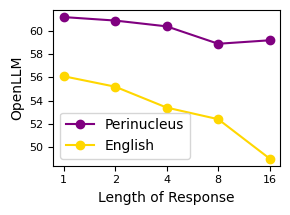

In [132]:
# https://wandb.ai/anshuln/llm_fingerprinting_long_response?nw=nwuseranasery2
inv_nuc = [61.2, 60.9, 60.4, 58.9, 59.2]
# english = [56.1, 52.6, 48.9, 46.6]  # Maybe redo these with smaller batch size
english = [56.1, 55.2, 53.4, 52.4, 49.0]  # Maybe redo these with smaller batch size

lengths = [1,2,4, 8, 16]

plt.figure(figsize=FIG_SIZE_MIDDLE)

plt.plot(lengths[:len(inv_nuc)], inv_nuc, label='Perinucleus', marker='o', color='purple', linestyle='-')
plt.plot(lengths[:len(english)], english, label='English', marker='o', color='gold', linestyle='-')

plt.xlabel("Length of Response")
plt.ylabel("OpenLLM")
plt.xscale('log')
plt.xticks(lengths, lengths)  # Explicitly set the numbers as labels
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)
plt.legend()
plt.tight_layout()
plt.savefig("plots/response_length.pdf")

## Fig 0.2 - Changing Width K

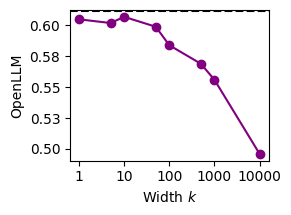

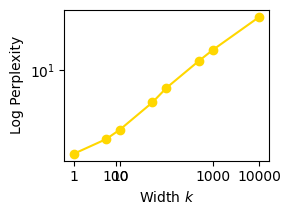

Coeff - [0.13808713], Intercept - 1.5023784903529425, R^2 - 0.993345865872616 when fitting log(nll) vs log(k)


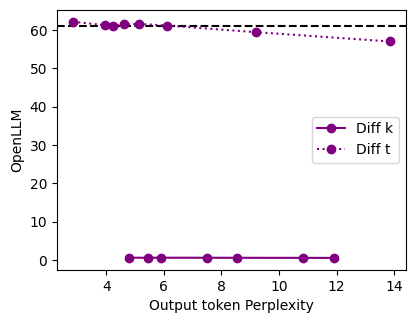

In [520]:
all_ks = [1, 5, 10, 50, 100, 500, 1000, 10000]
# https://wandb.ai/anshuln/llm_fingerprinting_llama_varying_k?nw=nwuseranasery2
perfs = np.array([60.5, 60.2, 60.7, 59.9, 58.4, 56.9, 55.6, 49.6])/100
all_ps = [4.77, 5.43, 5.91, 7.51, 8.53, 10.82, 11.92, 15.94]

plt.figure(figsize=FIG_SIZE_MIDDLE)
plt.plot(all_ks, perfs, label='OpenLLM', marker='o', color='purple', linestyle='-')
plt.xlabel("Width $k$")
plt.ylabel("OpenLLM")
plt.xscale('log')
plt.axhline(y=baseline_llama/100, color='black', linestyle='--', label='Llama Baseline')
plt.xticks([1, 10, 100, 1000, 10000], [1, 10, 100, 1000, 10000])  # Explicitly set the numbers as labels
# plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)
# Set precision to 2 on yaxis
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:.2f}"))
# plt.legend()
plt.tight_layout()
plt.savefig("plots/perinucleus_width.pdf", bbox_inches='tight')
plt.show()
plt.figure(figsize=FIG_SIZE_MIDDLE)
plt.plot(all_ks, all_ps, label='Perplexity', marker='o', color='gold', linestyle='-')
plt.xlabel("Width $k$")
plt.ylabel("Log Perplexity")
plt.xscale('log')
plt.yscale('log')

plt.xticks([1, 10, 10^2, 1000, 10000], [1, 10, 100, 1000, 10000])  # Explicitly set the numbers as labels
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)
# plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig("plots/perinucleus_width_perplexity.pdf")

# Compute a linear fit for log(perplexity) vs log(k)

import numpy as np
from sklearn.linear_model import LinearRegression
x = np.log(all_ks).reshape(-1, 1)
y = np.log(all_ps)
reg = LinearRegression().fit(x, y)
print(f"Coeff - {reg.coef_}, Intercept - {reg.intercept_}, R^2 - {reg.score(x, y)} when fitting log(nll) vs log(k)")
# print(reg.coef_)
# print(reg.intercept_)
# # Print the R^2 value
# print(reg.score(x, y))
# plt.figure(figsize=FIG_SIZE_BIG)
# Print the interpretation of the coefficient
# plt.close()
other_ppl = [2.831914188324596, 3.947650183071297, 4.240527072400182, 4.615220521841593, 5.149897361429764, 6.119297918617867, 9.210340371976182, 13.8499]
other_open_llm = [0.6221765555799329, 0.6127720040740151, 0.6118153474354472, 0.6152226381752569, 0.6162106633654797, 0.6119137295801867, 0.5946759359467261, 0.570519861813753]
plt.figure(figsize=FIG_SIZE_BIG)
plt.axhline(y=baseline_llama, color='black', linestyle='--')

plt.plot(all_ps[:-1], perfs[:-1], marker='o', color='purple', linestyle='-', label='Diff k')
plt.plot(other_ppl, np.array(other_open_llm)*100, marker='o', color='purple', linestyle=':', label='Diff t')

plt.xlabel("Output token Perplexity")
plt.ylabel("OpenLLM")
plt.legend()
plt.show()

ks = [1, 5, 10, 50, 100, 500, 1000, 10000]
persisitence = [93, 91.9, 91, 89.5, 86.9, 74.2, 78.5, 49.2]


# Representative Plots

## Fig 1 - Scaling FP

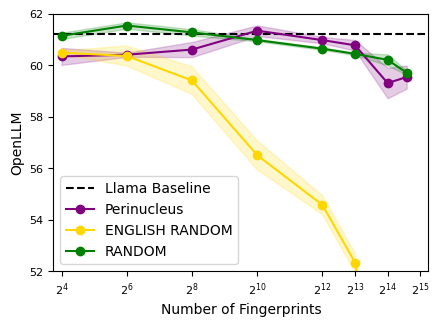

In [252]:
import matplotlib.pyplot as plt
import numpy as np

INVERASE_NUCLEUS_NAME = "Perinucleus"
RANDOM_NAME = "RANDOM"
ENGLISH_NAME = "ENGLISH RANDOM"

LINE_WIDTH = 6.75

HALF_WIDTH = 3.375
THIRD_WIDTH = 2.25
QUARTER_WIDTH = 1.6875

ASPECT_RATIO = 4/3

FIG_SIZE_BIG = (HALF_WIDTH*ASPECT_RATIO, HALF_WIDTH) # in inches
FIG_SIZE_MIDDLE = (THIRD_WIDTH*ASPECT_RATIO, THIRD_WIDTH) # in inches
FIG_SIZE_SMALL = (QUARTER_WIDTH*ASPECT_RATIO, QUARTER_WIDTH) # in inches 
FONT_SIZE_MAIN = 10
FONT_SIZE_SMALL = 8
plt.rc('font', size=FONT_SIZE_MAIN)          # controls default text sizes
plt.rc('axes', titlesize=FONT_SIZE_MAIN)     # fontsize of the axes title
plt.rc('axes', labelsize=FONT_SIZE_MAIN)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=FONT_SIZE_SMALL)    # fontsize of the tick labels
plt.rc('ytick', labelsize=FONT_SIZE_SMALL)    # fontsize of the tick labels
plt.rc('legend', fontsize=FONT_SIZE_MAIN)    # legend fontsize


fingerprints = [16, 64, 256, 1024, 4096, 8192, 16384, 24576]
baseline_llama = 61.2
# https://wandb.ai/anshuln/llm_fingerprinting_scaling_llama/panel/0leaafv9b?nw=nwuseranasery2
inv_nucleus = [60.7, 60.5, 60.3, 61.3, 61.1, 61.0, 59.9, 60.1]
inv_nucleus_seed_2 = [60.4,  60.3, 60.5, 61.1, 60.8, 60.5, 58.5 , 59.0]
inv_nucleus_seed_3 = [59.9, 60.4 , 61.0, 61.6, 61.0,60.8, 59.5, 59.5]
# Below two are from https://wandb.ai/anshuln/llm_fingerprinting_random_response_hp/panel/tc4nscjme?nw=nwuseranasery2
english_random = [60.55, 60.85, 60.0, 56.1, 54.1, 51.9,45, 40]
english_random_seed_2 = [60.4, 59.9, 59.5, 57.3, 55.0, 52.3, 45, 40]
english_random_seed_3 = [60.5, 60.3, 58.7, 56.1, 54.6 ,52.8, 45, 40]

random = [61.1, 61.4, 61.3, 60.9, 60.6, 60.4, 60.5, 59.6]
random_seed_2 = [61.0, 61.7, 61.1, 61.0, 60.7, 60.4, 60.0, 59.7]
random_seed_3 = [61.3, 61.5, 61.4, 61.0, 60.6, 60.5, 60.1, 59.8]

plt.figure(figsize=FIG_SIZE_BIG)

plt.plot(fingerprints[:len(inv_nucleus)], inv_nucleus, label=INVERASE_NUCLEUS_NAME, marker='o', color='purple', linestyle='-')
plt.plot(fingerprints[:len(english_random)], english_random, label=ENGLISH_NAME, marker='o', color='gold', linestyle='-')
plt.plot(fingerprints[:len(random)], random, label=RANDOM_NAME, marker='o', color='green', linestyle='-')
plt.xscale('log')
plt.xlabel("Number of Fingerprints")
plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels
plt.ylabel("OpenLLM")
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_8b_accuracy.pdf")
plt.close()

# Plot with standard deviation and mean
plt.figure(figsize=FIG_SIZE_BIG)
inv_nucleus_mean = np.mean([inv_nucleus, inv_nucleus_seed_2, inv_nucleus_seed_3], axis=0)
inv_nucleus_std = np.std([inv_nucleus, inv_nucleus_seed_2, inv_nucleus_seed_3], axis=0)
english_random_mean = np.mean([english_random, english_random_seed_2, english_random_seed_3], axis=0)
english_random_std = np.std([english_random, english_random_seed_2, english_random_seed_3], axis=0)
random_mean = np.mean([random, random_seed_2, random_seed_3], axis=0)
random_std = np.std([random, random_seed_2, random_seed_3], axis=0)

plt.axhline(y=baseline_llama, color='black', linestyle='--', label='Llama Baseline')
# Plot a region with mean and standard deviation
plt.fill_between(fingerprints[:len(inv_nucleus)], inv_nucleus_mean - inv_nucleus_std, inv_nucleus_mean + inv_nucleus_std, alpha=0.2, color='purple')
plt.plot(fingerprints[:len(inv_nucleus)], inv_nucleus_mean, label=INVERASE_NUCLEUS_NAME, marker='o', color='purple', linestyle='-')
plt.fill_between(fingerprints[:len(english_random)], english_random_mean - english_random_std, english_random_mean + english_random_std, alpha=0.2, color='gold')
plt.plot(fingerprints[:len(english_random)], english_random_mean, label=ENGLISH_NAME, marker='o', color='gold', linestyle='-')
plt.fill_between(fingerprints[:len(random)], random_mean - random_std, random_mean + random_std, alpha=0.2, color='green')
plt.plot(fingerprints[:len(random)], random_mean, label=RANDOM_NAME, marker='o', color='green', linestyle='-')

# plt.errorbar(fingerprints[:len(inv_nucleus)], inv_nucleus_mean, yerr=inv_nucleus_std, label=INVERASE_NUCLEUS_NAME, marker='o', color='purple', linestyle='-')
# plt.errorbar(fingerprints[:len(english_random)], english_random_mean, yerr=english_random_std, label=ENGLISH_NAME, marker='o', color='gold', linestyle='-')
# plt.errorbar(fingerprints[:len(random)], random_mean, yerr=random_std, label=RANDOM_NAME, marker='o', color='green', linestyle='-')
plt.xscale('log')
plt.xlabel("Number of Fingerprints")
# plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels

plt.xticks(fingerprints[:-1]+[2**15], [f"$2^{{{int(np.round(np.log2(x)))}}}$" for x in fingerprints[:-1]+[2**15]])

# Remove minor ticks and keep major ticks only at the desired values
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)

plt.ylabel("OpenLLM")
plt.ylim(52, 62)
plt.xlim(2**3.75, 2**15.25)
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_8b_accuracy_errors.pdf")

## Fig 2 - Persistence of FP

7 7 7


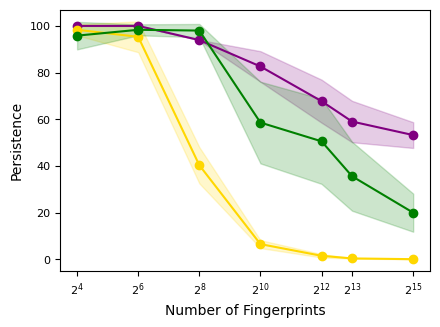

In [131]:
import matplotlib.pyplot as plt
def convert_persistence_to_fp(persistence, fps):
    return [x*y/100 for x, y in zip(persistence, fps)]

fingerprints = [16, 64, 256, 1024, 4096, 8192, 16384, 2**15]

# https://wandb.ai/anshuln/llm_fingerprints_forgetting_llama/panel/6nyudg60k?nw=nwuseranasery2
inv_nucleus = [100, 100, 93.8, 73.4, 54.8, 46.5]
inv_nucleus_seed_2 = [100, 100, 94.0, 86.7, 75.4, 65.6]
inv_nucleus_seed_3 = [100, 100, 94.0, 87.8, 73.1, 65.0]
# inv_nucleus = [100, 100, 93.8, 73.4, 54.8, 46.5, 55.1, 48.7]
# inv_nucleus_seed_2 = [100, 100, 94.0, 86.7, 75.4, 65.6, 71, 61]
# inv_nucleus_seed_3 = [100, 100, 94.0, 87.8, 73.1, 65.0, 70, 58]


random = [87.5,95 , 94, 83, 67.6, 54.3]  # Re-do some of these
# random = [87.5,95 , 94, 83, 67.6, 54.3, 52.1, 30]  # Redo the biggest
random_seed_2 = [100, 100, 100, 49.9, 58.8, 18.2]
# random_seed_2 = [100, 100, 100, 49.9, 58.8, 18.2, 17, 10]
random_seed_3 = [100, 100, 100, 42.9, 25.3 , 34.3]
# random_seed_3 = [100, 100, 100, 42.9, 25.3 , 34.3, 33, 20]  # Redo the biggest

english_random = [95, 86, 31, 5, 2, 0.5]
english_random_seed_2 = [100, 100, 50, 5.7, 0.5, 0.3]  # Redo the 256 ? 
english_random_seed_3 = [100, 100, 40, 8.9, 2.1, 0.4]

plt.figure(figsize=FIG_SIZE_BIG)
plt.plot(fingerprints[:len(inv_nucleus)], inv_nucleus, label=INVERASE_NUCLEUS_NAME, marker='o', color='purple', linestyle='-')
plt.plot(fingerprints[:len(english_random)], english_random, label=ENGLISH_NAME, marker='o', color='gold', linestyle='-')
plt.plot(fingerprints[:len(random)], random, label=RANDOM_NAME, marker='o', color='green', linestyle='-')
plt.xscale('log')
plt.xlabel("Number of Fingerprints")
plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels
plt.ylabel("Persistence")
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_8b_forgetting_clean.pdf")
plt.close()
# Plot with standard deviation and mean
plt.figure(figsize=FIG_SIZE_BIG)
inv_nucleus_mean = np.mean([inv_nucleus, inv_nucleus_seed_2, inv_nucleus_seed_3], axis=0)
inv_nucleus_std = np.std([inv_nucleus, inv_nucleus_seed_2, inv_nucleus_seed_3], axis=0)
english_random_mean = np.mean([english_random, english_random_seed_2, english_random_seed_3], axis=0)
english_random_std = np.std([english_random, english_random_seed_2, english_random_seed_3], axis=0)
random_mean = np.mean([random, random_seed_2, random_seed_3], axis=0)
random_std = np.std([random, random_seed_2, random_seed_3], axis=0)

# Plot a region with mean and standard deviation
plt.fill_between(fingerprints[:len(inv_nucleus)], inv_nucleus_mean - inv_nucleus_std, inv_nucleus_mean + inv_nucleus_std, alpha=0.2, color='purple')
plt.plot(fingerprints[:len(inv_nucleus)], inv_nucleus_mean, label=INVERASE_NUCLEUS_NAME, marker='o', color='purple', linestyle='-')
plt.fill_between(fingerprints[:len(english_random)], english_random_mean - english_random_std, english_random_mean + english_random_std, alpha=0.2, color='gold')
plt.plot(fingerprints[:len(english_random)], english_random_mean, label=ENGLISH_NAME, marker='o', color='gold', linestyle='-')
plt.fill_between(fingerprints[:len(random)], random_mean - random_std, random_mean + random_std, alpha=0.2, color='green')
plt.plot(fingerprints[:len(random)], random_mean, label=RANDOM_NAME, marker='o', color='green', linestyle='-')

plt.xscale('log')
plt.xlabel("Number of Fingerprints")


plt.xticks(fingerprints, [f"$2^{{{int(np.log2(x))}}}$" for x in fingerprints])

# Remove minor ticks and keep major ticks only at the desired values
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)
# plt.xticks(fingerprints, [f"2^{int(np.log2(x))}" for x in fingerprints])  # Explicitly set the numbers as labels
# plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels
plt.ylabel("Persistence")
# plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_8b_forgetting_error_bars.pdf")
plt.close()

# fingerprints = [16, 64, 256, 1024, 4096, 8192, 16384, 2**15]
fingerprints = [16, 64, 256, 1024, 4096, 8192, 2**15]

inv_nucleus = [100, 100, 93.8, 73.4, 54.8, 46.5,  48.7]
inv_nucleus_seed_2 = [100, 100, 94.0, 86.7, 75.4, 65.6, 61]
inv_nucleus_seed_3 = [100, 100, 94.0, 87.8, 73.1, 65.0, 50]

random = [87.5,95 , 94, 83, 67.6, 54.3,  30] 
random_seed_2 = [100, 100, 100, 49.9, 58.8, 18.2, 10]
random_seed_3 = [100, 100, 100, 42.9, 25.3 , 34.3, 20]


english_random = [95, 86, 31, 5, 2, 0.5, 0.1]
english_random_seed_2 = [100, 100, 50, 5.7, 0.5, 0.3, 0.05]  # Redo the 256 ? 
english_random_seed_3 = [100, 100, 40, 8.9, 2.1, 0.4, 0.1]

plt.figure(figsize=FIG_SIZE_BIG)
inv_nucleus_mean = np.mean([inv_nucleus, inv_nucleus_seed_2, inv_nucleus_seed_3], axis=0)
inv_nucleus_std = np.std([inv_nucleus, inv_nucleus_seed_2, inv_nucleus_seed_3], axis=0)
english_random_mean = np.mean([english_random, english_random_seed_2, english_random_seed_3], axis=0)
english_random_std = np.std([english_random, english_random_seed_2, english_random_seed_3], axis=0)
random_mean = np.mean([random, random_seed_2, random_seed_3], axis=0)
random_std = np.std([random, random_seed_2, random_seed_3], axis=0)

# Plot a region with mean and standard deviation
print(len(fingerprints), len(inv_nucleus_mean), len(inv_nucleus_std))
plt.fill_between(fingerprints[:len(inv_nucleus)], inv_nucleus_mean - inv_nucleus_std, inv_nucleus_mean + inv_nucleus_std, alpha=0.2, color='purple')
plt.plot(fingerprints[:len(inv_nucleus)], inv_nucleus_mean, label=INVERASE_NUCLEUS_NAME, marker='o', color='purple', linestyle='-')
plt.fill_between(fingerprints[:len(english_random)], english_random_mean - english_random_std, english_random_mean + english_random_std, alpha=0.2, color='gold')
plt.plot(fingerprints[:len(english_random)], english_random_mean, label=ENGLISH_NAME, marker='o', color='gold', linestyle='-')
plt.fill_between(fingerprints[:len(random)], random_mean - random_std, random_mean + random_std, alpha=0.2, color='green')
plt.plot(fingerprints[:len(random)], random_mean, label=RANDOM_NAME, marker='o', color='green', linestyle='-')

plt.xscale('log')
plt.xlabel("Number of Fingerprints")


plt.xticks(fingerprints, [f"$2^{{{int(np.log2(x))}}}$" for x in fingerprints])

# Remove minor ticks and keep major ticks only at the desired values
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)
# plt.xticks(fingerprints, [f"2^{int(np.log2(x))}" for x in fingerprints])  # Explicitly set the numbers as labels
# plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels
plt.ylabel("Persistence")
# plt.legend()
plt.tight_layout()
# plt.show()
plt.savefig("plots/llama_8b_forgetting_error_bars_larger.pdf")

### Fig 3.3 Num fp instead of persistence

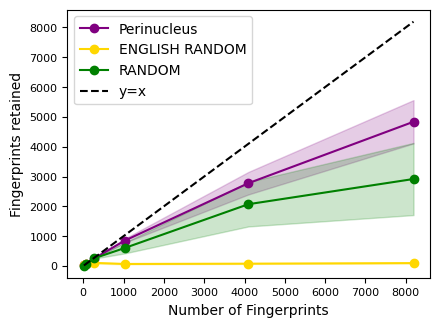

In [253]:
fingerprints = [16, 64, 256, 1024, 4096, 8192]

# https://wandb.ai/anshuln/llm_fingerprints_forgetting_llama/panel/6nyudg60k?nw=nwuseranasery2
inv_nucleus = [100, 100, 93.8, 73.4, 54.8, 46.5]
inv_nucleus_seed_2 = [100, 100, 94.0, 86.7, 75.4, 65.6]
inv_nucleus_seed_3 = [100, 100, 94.0, 87.8, 73.1, 65.0]
# inv_nucleus = [100, 100, 93.8, 73.4, 54.8, 46.5, 55.1, 48.7]
# inv_nucleus_seed_2 = [100, 100, 94.0, 86.7, 75.4, 65.6, 71, 61]
# inv_nucleus_seed_3 = [100, 100, 94.0, 87.8, 73.1, 65.0, 70, 58]


random = [87.5,95 , 94, 83, 67.6, 54.3]  # Re-do some of these
# random = [87.5,95 , 94, 83, 67.6, 54.3, 52.1, 30]  # Redo the biggest
random_seed_2 = [100, 100, 100, 49.9, 58.8, 18.2]
# random_seed_2 = [100, 100, 100, 49.9, 58.8, 18.2, 17, 10]
random_seed_3 = [100, 100, 100, 42.9, 25.3 , 34.3]
# random_seed_3 = [100, 100, 100, 42.9, 25.3 , 34.3, 33, 20]  # Redo the biggest

english_random = [95, 86, 31, 5, 2, 1.0]
english_random_seed_2 = [100, 100, 50, 5.7, 1.5, 1.3]  # Redo the 256 ? 
english_random_seed_3 = [100, 100, 40, 8.9, 2.1, 1.2]

# Plot with standard deviation and mean
plt.figure(figsize=FIG_SIZE_BIG)

inv_nucleus = convert_persistence_to_fp(inv_nucleus, fingerprints)
inv_nucleus_seed_2 = convert_persistence_to_fp(inv_nucleus_seed_2, fingerprints)
inv_nucleus_seed_3 = convert_persistence_to_fp(inv_nucleus_seed_3, fingerprints)

random = convert_persistence_to_fp(random, fingerprints)
random_seed_2 = convert_persistence_to_fp(random_seed_2, fingerprints)
random_seed_3 = convert_persistence_to_fp(random_seed_3, fingerprints)

english_random = convert_persistence_to_fp(english_random, fingerprints)
english_random_seed_2 = convert_persistence_to_fp(english_random_seed_2, fingerprints)
english_random_seed_3 = convert_persistence_to_fp(english_random_seed_3, fingerprints)



inv_nucleus_mean = np.mean([inv_nucleus, inv_nucleus_seed_2, inv_nucleus_seed_3], axis=0)
inv_nucleus_std = np.std([inv_nucleus, inv_nucleus_seed_2, inv_nucleus_seed_3], axis=0)
english_random_mean = np.mean([english_random, english_random_seed_2, english_random_seed_3], axis=0)
english_random_std = np.std([english_random, english_random_seed_2, english_random_seed_3], axis=0)
random_mean = np.mean([random, random_seed_2, random_seed_3], axis=0)
random_std = np.std([random, random_seed_2, random_seed_3], axis=0)

# Plot a region with mean and standard deviation
plt.fill_between(fingerprints[:len(inv_nucleus)], inv_nucleus_mean - inv_nucleus_std, inv_nucleus_mean + inv_nucleus_std, alpha=0.2, color='purple')
plt.plot(fingerprints[:len(inv_nucleus)], inv_nucleus_mean, label=INVERASE_NUCLEUS_NAME, marker='o', color='purple', linestyle='-')
plt.fill_between(fingerprints[:len(english_random)], english_random_mean - english_random_std, english_random_mean + english_random_std, alpha=0.2, color='gold')
plt.plot(fingerprints[:len(english_random)], english_random_mean, label=ENGLISH_NAME, marker='o', color='gold', linestyle='-')
plt.fill_between(fingerprints[:len(random)], random_mean - random_std, random_mean + random_std, alpha=0.2, color='green')
plt.plot(fingerprints[:len(random)], random_mean, label=RANDOM_NAME, marker='o', color='green', linestyle='-')

# Add a line with y=x
plt.plot(fingerprints, fingerprints, label='y=x', color='black', linestyle='--')

# plt.xscale('log')
plt.xlabel("Number of Fingerprints")


# plt.xticks(fingerprints, [f"$2^{{{int(np.log2(x))}}}$" for x in fingerprints])

# Remove minor ticks and keep major ticks only at the desired values
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)
# plt.xticks(fingerprints, [f"2^{int(np.log2(x))}" for x in fingerprints])  # Explicitly set the numbers as labels
# plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels
plt.ylabel("Fingerprints retained")
# plt.yscale('log')
# plt.yticks(fingerprints, [f"$2^{{{int(np.log2(x))}}}$" for x in fingerprints])
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_8b_forgetting_num_fp_error_bars.pdf")
# plt.close()

## Fig 3.1 - Using meta-learning

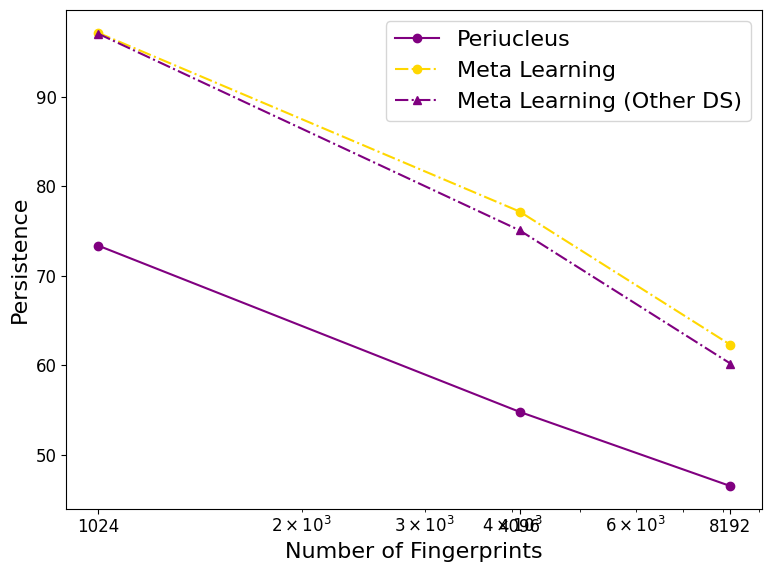

In [30]:
# https://wandb.ai/anshuln/llm_fingerprints_forgetting_meta_learning_llama?nw=nwuseranasery2&panelDisplayName=fractional_fingerprint_accuracy&panelSectionName=Charts
fingerprints = [1024, 4096, 8192]
inv_nucleus = [73.4, 54.8, 46.5]
inv_nucleus_meta = [97.2, 77.2, 62.3]
inv_nucleus_other_meta = [97.1, 75.1, 60.2] # Some of these are wrong

plt.figure(figsize=FIG_SIZE_BIG)
plt.plot(fingerprints, inv_nucleus, label=INVERASE_NUCLEUS_NAME, marker='o', color='purple', linestyle='-')
plt.plot(fingerprints, inv_nucleus_meta, label="Meta Learning", marker='o', color='gold', linestyle='-.')
plt.plot(fingerprints, inv_nucleus_other_meta, label="Meta Learning (Other DS)", marker='^', color='purple', linestyle='-.')
plt.xscale('log')
plt.xlabel("Number of Fingerprints")
plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels
plt.ylabel("Persistence")
plt.legend()
plt.tight_layout()

plt.savefig("plots/llama_8b_meta_learning.pdf")

## Fig 3.2 - Different dataset sizes for persistence

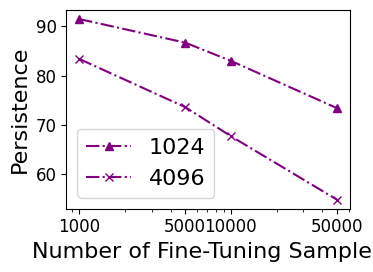

In [43]:
ft_samples = [1000, 5000, 10000, 50000]
persistence_1024 = [91.5, 86.7, 83, 73.4]
persistence_4096 = [83.4, 73.6, 67.7, 54.8]
# https://wandb.ai/anshuln/llm_fingerprints_forgetting_llama/panel/6nyudg60k?nw=nwuseranasery2

plt.figure(figsize=FIG_SIZE_SMALL)
plt.plot(ft_samples, persistence_1024, label="1024", marker='^', color='purple', linestyle='-.')
plt.plot(ft_samples, persistence_4096, label="4096", marker='x', color='purple', linestyle='-.')
plt.xscale('log')
plt.xlabel("Number of Fine-Tuning Samples")
plt.xticks(ft_samples, ft_samples)  # Explicitly set the numbers as labels
plt.ylabel("Persistence")
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_8b_ft_samples.pdf")

## Fig 3.3 - Different datasets for persistence

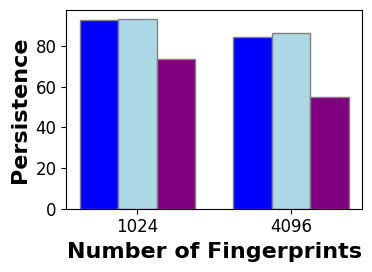

In [46]:
# https://wandb.ai/anshuln/llm_fingerprints_forgetting_llama/panel/6nyudg60k?nw=nwuseranasery2

math_instruct = [92.7, 84.2]
math_instruct_50k = [93.0, 86.5]
alpaca = [73.4, 54.8]
dpo = [61.5, 40.0]

# Make a bar chart
barWidth = 0.25
r1 = np.arange(len(math_instruct))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
r4 = [x + barWidth for x in r3]
plt.figure(figsize=FIG_SIZE_SMALL)
plt.bar(r1, math_instruct, color='blue', width=barWidth, edgecolor='grey', label='MathInstruct')
plt.bar(r2, math_instruct_50k, color='lightblue', width=barWidth, edgecolor='grey', label='MathInstruct-50k')
plt.bar(r3, alpaca, color='purple', width=barWidth, edgecolor='grey', label='Alpaca')
plt.bar(r4, dpo, color='green', width=barWidth, edgecolor='grey', label='DPO')
plt.xlabel('Number of Fingerprints')
plt.xticks([r + barWidth for r in range(len(math_instruct))], ['1024', '4096'])
plt.ylabel('Persistence')
# Make legend horizontal at the top
plt.rc('legend', fontsize=FONT_SIZE_SMALL)    # legend fontsize
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), shadow=True, ncol=3)
plt.tight_layout()
plt.savefig("plots/llama_8b_ft_dataset_with_dpo.pdf")

## Fig 3.4 Persistence with epochs

In [ ]:
import matplotlib.pyplot as plt
ft_samples = [1, 2, 3, 4]
persistence_1024 = [79.2 , 73.4, 72.3,72]
# persistence_4096 = [83.4, 73.6, 67.7, 54.8]
# https://wandb.ai/anshuln/llm_fingerprints_forgetting_llama/panel/6nyudg60k?nw=nwuseranasery2

plt.figure(figsize=FIG_SIZE_SMALL)
plt.plot(ft_samples, persistence_1024, label="1024", marker='^', color='purple', linestyle='-.')
# plt.plot(ft_samples, persistence_4096, label="4096", marker='x', color='purple', linestyle='-.')
# plt.xscale('log')
plt.xlabel("Finetuning Epochs")
plt.xticks(ft_samples, ft_samples)  # Explicitly set the numbers as labels
plt.ylabel("Persistence")
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_8b_ft_epochs.pdf")

## Fig 4 - Scaling performance

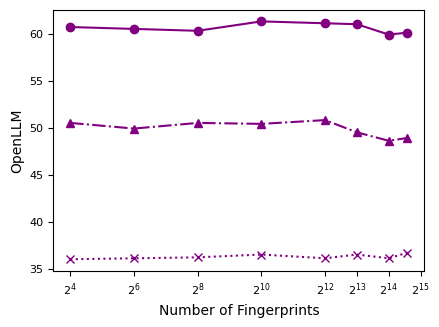

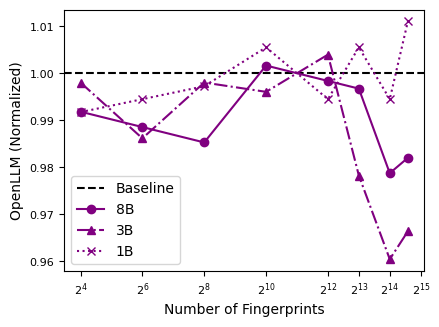

In [255]:
fingerprints = [16, 64, 256, 1024, 4096, 8192, 16384, 24576]
inv_nucleus_8B = np.array([60.7, 60.5, 60.3, 61.3, 61.1, 61.0, 59.9, 60.1])

# https://wandb.ai/anshuln/llm_fingerprinting_3B?nw=nwuseranasery2
# https://wandb.ai/anshuln/llm_fingerprinting_llama_1b?nw=nwuseranasery2
inv_nucleus_3B = np.array([50.5, 49.9, 50.5, 50.4, 50.8, 49.5, 48.6, 48.9 ])
inv_nucleus_1B = np.array([36.0, 36.1, 36.2, 36.5, 36.1, 36.5, 36.1, 36.7])

baseline_llama = 61.2
baseline_llama_3B = 50.6
baseline_llama_1B = 36.3


plt.figure(figsize=FIG_SIZE_BIG)
plt.plot(fingerprints[:len(inv_nucleus_8B)], inv_nucleus_8B, label="8B", marker='o', color='purple', linestyle='-')
plt.plot(fingerprints[:len(inv_nucleus_3B)], inv_nucleus_3B, label="3B", marker='^', color='purple', linestyle='-.')
plt.plot(fingerprints[:len(inv_nucleus_1B)], inv_nucleus_1B, label="1B", marker='x', color='purple', linestyle=':')
plt.xscale('log')
plt.xlabel("Number of Fingerprints")
# plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels

plt.xticks(fingerprints[:-1]+[2**15], [f"$2^{{{int(np.round(np.log2(x)))}}}$" for x in fingerprints[:-1]+[fingerprints[-1]]])

# Remove minor ticks and keep major ticks only at the desired values
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)


plt.ylabel("OpenLLM")
# plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_3B_8B_accuracy.pdf")

plt.figure(figsize=FIG_SIZE_BIG)
plt.axhline(y=1.0, color='black', linestyle='--', label='Baseline')
plt.plot(fingerprints[:len(inv_nucleus_8B)], inv_nucleus_8B / baseline_llama, label="8B", marker='o', color='purple', linestyle='-')
plt.plot(fingerprints[:len(inv_nucleus_3B)], inv_nucleus_3B / baseline_llama_3B, label="3B", marker='^', color='purple', linestyle='-.')
plt.plot(fingerprints[:len(inv_nucleus_1B)], inv_nucleus_1B / baseline_llama_1B, label="1B", marker='x', color='purple', linestyle=':')
plt.xscale('log')
plt.xlabel("Number of Fingerprints")
# plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels

plt.xticks(fingerprints[:-1]+[2**15], [f"$2^{{{int(np.round(np.log2(x)))}}}$" for x in fingerprints[:-1]+[fingerprints[-1]]])

# Remove minor ticks and keep major ticks only at the desired values
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)


plt.ylabel("OpenLLM (Normalized)")
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_3B_8B_accuracy_relative.pdf")

## Fig 4.2 Scaling Persistence

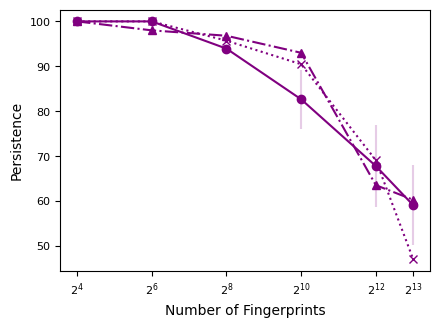

In [295]:
fingerprints = [16, 64, 256, 1024, 4096, 8192]

persistence_8b = [100, 100, 93.8, 73.4, 54.8, 46.5]
persistence_8b_seed_2 = [100, 100, 94.0, 86.7, 75.4, 65.6]
persistence_8b_seed_3 = [100, 100, 94.0, 87.8, 73.1, 65.0]

inv_nucleus = [100, 100, 93.8, 73.4, 54.8, 46.5]
inv_nucleus_seed_2 = [100, 100, 94.0, 86.7, 75.4, 65.6]

# https://wandb.ai/anshuln/llm_fingerprints_forgetting_llama_3B?nw=nwuseranasery2
# https://wandb.ai/anshuln/llm_fingerprints_forgetting_llama_1b?nw=nwuseranasery2
persistence_3b = [100, 98, 96.8,88.9, 56.7, 51.2 ]
persistence_3b_seed_2 = [100, 98, 96.8,97.1, 70.3, 69.3 ]

persistence_1b = [100, 100, 95.7, 89.5, 67.8, 46.2]
persistence_1b_seed_2 = [100, 100, 95.7, 91.4, 70.3, 47.8]


persistence_8b_std = np.std([persistence_8b, persistence_8b_seed_2, persistence_8b_seed_3], axis=0)
persistence_3b_std = np.std([persistence_3b, persistence_3b_seed_2], axis=0)
persistence_1b_std = np.std([persistence_1b, persistence_1b_seed_2], axis=0)

persistence_8b = np.mean([persistence_8b, persistence_8b_seed_2, persistence_8b_seed_3], axis=0)
persistence_3b = np.mean([persistence_3b, persistence_3b_seed_2], axis=0)
persistence_1b = np.mean([persistence_1b, persistence_1b_seed_2], axis=0)


plt.figure(figsize=FIG_SIZE_BIG)
plt.errorbar(fingerprints[:len(persistence_8b)], persistence_8b, yerr=persistence_8b_std, linestyle='None', color='#E6CCE6')
plt.plot(fingerprints[:len(persistence_8b)], persistence_8b, label="8B", marker='o', color='purple', linestyle='-')

plt.plot(fingerprints[:len(persistence_3b)], persistence_3b, label="3B", marker='^', color='purple', linestyle='-.')
# plt.errorbar(fingerprints[:len(persistence_3b)], persistence_3b, yerr=persistence_3b_std, linestyle='-.', color='purple')

plt.plot(fingerprints[:len(persistence_1b)], persistence_1b, label="1B", marker='x', color='purple', linestyle=':')
# plt.errorbar(fingerprints[:len(persistence_1b)], persistence_1b, yerr=persistence_1b_std, linestyle=':', color='purple')

plt.xscale('log')
plt.xlabel("Number of Fingerprints")
# plt.xticks(fingerprints, fingerprints)  # Explicitly set the numbers as labels


plt.xticks(fingerprints, [f"$2^{{{int(np.round(np.log2(x)))}}}$" for x in fingerprints])

# Remove minor ticks and keep major ticks only at the desired values
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)

plt.ylabel("Persistence")
# plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_3B_8B_forgetting_more_seeds.pdf")

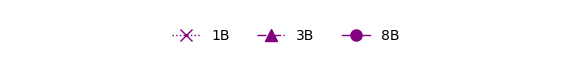

In [282]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Create a legend-only figure
fig, ax = plt.subplots(figsize=(6, 1))  # Adjust size for the legend

# Define legend elements
legend_labels = ['1B', '3B', '8B']
line_styles = [':', '-.', '-']
legend_markers = ['x', '^', 'o']
handles = [
    Line2D(
        [0], [0], 
        color='purple', 
        linestyle=style, 
        marker=marker, 
        markersize=8, 
        linewidth=1, 
        label=label
    )
    for style, marker, label in zip(line_styles, legend_markers, legend_labels)
]

# Add legend to the figure
legend = ax.legend(handles=handles, loc='center', ncol=3, frameon=False, fontsize=10)
ax.axis('off')  # Remove axes

# Save the legend as a PDF
fig.tight_layout()
fig.savefig("plots/shared_legend_scaling_model.pdf", bbox_inches='tight')


## Fig 5.1 Other Model Fingerprints Performance

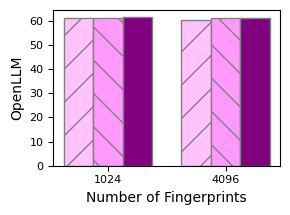

In [278]:
# https://wandb.ai/anshuln/llm_fingerprinting_llama_other_model_fp?nw=nwuseranasery2
fingerprints = [1024, 4096]
inv_nucleus = [61.3, 61.1]
inv_nucleus_3b = [61.1, 61.1]
inv_nucleus_1b = [60.9, 60.3]
# inv_nucleus_mistral = [60.7, 59.8 ]
inv_nucleus_3b_5e_5 = [60.3, 60.3]
inv_nucleus_1b_5e_5 = [59.9, 59.8]

# Make a bar plot
barWidth = 0.25
r1 = np.arange(len(inv_nucleus))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
plt.figure(figsize=FIG_SIZE_MIDDLE)

plt.bar(r1, inv_nucleus_1b, color='#FFC2FD', width=barWidth, edgecolor='grey', hatch='/',label='1B')
plt.bar(r2, inv_nucleus_3b, color='#FF99FC', width=barWidth, edgecolor='grey', hatch='\\', label='3B')
plt.bar(r3, inv_nucleus, color='purple', width=barWidth, edgecolor='grey', hatch='', label='8B')

plt.xlabel('Number of Fingerprints')
plt.xticks([r + barWidth for r in range(len(inv_nucleus))], ['1024', '4096'])
plt.ylabel('OpenLLM')
# Make legend horizontal at the top
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), shadow=True, ncol=3)
plt.tight_layout()
plt.savefig("plots/llama_other_model_fp.pdf")




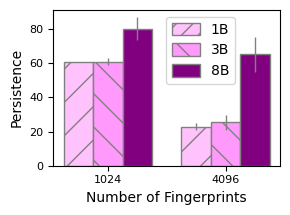

In [280]:
inv_nucleus = [73.4, 54.8]
inv_nucleus_s2 = [86.7, 75.4]
inv_nucleus_s3 = [87.8, 73.1]

inv_nucleus_mean = np.mean([inv_nucleus, inv_nucleus_s2, inv_nucleus_s3], axis=0)
inv_nuc_std = np.std([inv_nucleus, inv_nucleus_s2, inv_nucleus_s3], axis=0)

inv_nucleus_3b = [62.9, 29.7] 
inv_nucleus_3b_s2 = [58.6, 21.0] 

inv_nucleus_3b_mean = np.mean([inv_nucleus_3b, inv_nucleus_3b_s2], axis=0)
inv_nucleus_3b_std = np.std([inv_nucleus_3b, inv_nucleus_3b_s2], axis=0)

inv_nucleus_1b = [60.4, 24.8]
inv_nucleus_1b_s2 = [60.7, 20.7]

inv_nucleus_1b_mean = np.mean([inv_nucleus_1b, inv_nucleus_1b_s2], axis=0)
inv_nucleus_1b_std = np.std([inv_nucleus_1b, inv_nucleus_1b_s2], axis=0)

# inv_nucleus_mistral = [60.7, 59.8 ]
inv_nucleus_3b_5e_5 = [90.3, 76.1]
inv_nucleus_1b_5e_5 = [90.1, 74.3]

# inv_nucleus_mistral = [55.5, 45.1] # Placeholders
# inv_nucleus_1b = [, 74.3] # Placeholders

# Make a bar plot
barWidth = 0.25
r1 = np.arange(len(inv_nucleus))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
plt.figure(figsize=FIG_SIZE_MIDDLE)

# Plot mean and standard deviation
# plt.errorbar(r1, inv_nucleus, yerr=[inv_nucleus, inv_nucleus_s2], color='purple', linestyle='None')
# plt.errorbar(r2, inv_nucleus_3b, yerr=[inv_nucleus_3b, inv_nucleus_3b_s2], color='#FF99FC', linestyle='None')
# plt.errorbar(r3, inv_nucleus_1b, yerr=[inv_nucleus_1b, inv_nucleus_1b_s2], color='#FFC2FD', linestyle='None')

# # Plot the mean
# plt.plot(r1, inv_nucleus_mean, color='purple', marker='o', linestyle='-', label='8B')
# plt.plot(r2, inv_nucleus_3b_mean, color='#FF99FC', marker='^', linestyle='-.', label='3B')
# plt.plot(r3, inv_nucleus_1b_mean, color='#FFC2FD', marker='x', linestyle=':', label='Mistral')


plt.bar(r1, inv_nucleus_1b, color='#FFC2FD', width=barWidth, edgecolor='grey', hatch='\\', label='Mistral')
plt.bar(r2, inv_nucleus_3b, color='#FF99FC', width=barWidth, edgecolor='grey', hatch='/', label='3B')
plt.bar(r3, inv_nucleus, color='purple', width=barWidth, edgecolor='grey', label='8B')

plt.xlabel('Number of Fingerprints')
plt.xticks([r + barWidth for r in range(len(inv_nucleus))], ['1024', '4096'])
plt.ylabel('Persistence')
# Make legend horizontal at the top
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), shadow=True, ncol=3)
plt.tight_layout()
plt.savefig("plots/llama_other_model_fp_forgetting.pdf")
plt.close()

# barWidth = 0.25
# r1 = np.arange(len(inv_nucleus))
# r2 = [x + barWidth for x in r1]
# r3 = [x + barWidth for x in r2]
# plt.figure(figsize=FIG_SIZE_MIDDLE)

# # Plot mean and standard deviation
# plt.bar(r1, inv_nucleus_1b_mean, yerr=inv_nucleus_1b_std, color='#FFC2FD', edgecolor='grey')
# plt.bar(r2, inv_nucleus_3b_mean, yerr=inv_nucleus_3b_std, color='#FF99FC', edgecolor='grey')
# plt.bar(r3, inv_nucleus_mean, yerr=inv_nuc_std, color='purple', edgecolor='grey')

# # Plot the mean
# # plt.bar(r1, inv_nucleus_1b_mean, color='#FFC2FD', width=barWidth, edgecolor='grey', label='Mistral')
# # plt.bar(r2, inv_nucleus_3b_mean, color='#FF99FC', width=barWidth, edgecolor='grey', label='3B')
# # plt.bar(r3, inv_nucleus_mean, color='purple', width=barWidth, edgecolor='grey', label='8B')

# plt.show()
# plt.close()


inv_nucleus_mean = np.mean([inv_nucleus, inv_nucleus_s2], axis=0)
inv_nucleus_std = np.std([inv_nucleus, inv_nucleus_s2], axis=0)

inv_nucleus_3b_mean = np.mean([inv_nucleus_3b, inv_nucleus_3b_s2], axis=0)
inv_nucleus_3b_std = np.std([inv_nucleus_3b, inv_nucleus_3b_s2], axis=0)

inv_nucleus_1b_mean = np.mean([inv_nucleus_1b, inv_nucleus_1b_s2], axis=0)
inv_nucleus_1b_std = np.std([inv_nucleus_1b, inv_nucleus_1b_s2], axis=0)

# Bar width and positions
barWidth = 0.25
r1 = np.arange(len(inv_nucleus_mean))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
plt.figure(figsize=FIG_SIZE_MIDDLE)

# plt.figure(figsize=(8, 6))

# Plot bars with error bars (now using standard deviation)
plt.bar(r1, inv_nucleus_1b_mean, yerr=inv_nucleus_1b_std, color='#FFC2FD', width=barWidth, edgecolor='grey', label='1B', hatch='/',error_kw={'elinewidth': 1, 'ecolor': 'grey'})
plt.bar(r2, inv_nucleus_3b_mean, yerr=inv_nucleus_3b_std, color='#FF99FC', width=barWidth, edgecolor='grey', label='3B', hatch='\\',error_kw={'elinewidth': 1, 'ecolor': 'grey'})
plt.bar(r3, inv_nucleus_mean, yerr=inv_nucleus_std, color='purple', width=barWidth, edgecolor='grey', label='8B',error_kw={'elinewidth': 1, 'ecolor': 'grey'})

# Labels and formatting
plt.xlabel('Number of Fingerprints')
plt.xticks([r + barWidth for r in range(len(inv_nucleus_mean))], ['1024', '4096'])
plt.ylabel('Persistence')

from matplotlib import patches as mpatches
# Legend
# plt.legend(ncol=1, loc='upper center', bbox_to_anchor=(0.65, 1.0), shadow=False,)
legend_patches = [
    mpatches.Patch(facecolor='#FFC2FD', edgecolor='grey', hatch='//', label='1B'),
    mpatches.Patch(facecolor='#FF99FC', edgecolor='grey', hatch='\\', label='3B'),
    mpatches.Patch(facecolor='purple', edgecolor='grey', label='8B')
]

# Add legend using manually created patches
plt.legend(handles=legend_patches, ncol=1, loc='upper center', bbox_to_anchor=(0.65, 1.0), shadow=False, handleheight=1.0)
# Layout and display the plot
plt.tight_layout()
plt.savefig("plots/llama_other_model_fp_forgetting.pdf")
# plt.close()
# plt.show()

# import matplotlib.pyplot as plt

# fig, ax = plt.subplots()
# ax.bar([], [], color='#FFC2FD', label='1B')
# ax.bar([], [], color='#FF99FC', label='3B')
# ax.bar([], [], color='purple', label='8B')
# legend = ax.legend(loc='center', shadow=True, ncol=3, bbox_to_anchor=(0.5, 0.5))
# fig.savefig("plots/shared_legend_diff_fp.pdf", bbox_inches='tight')
# plt.close(fig)


# fig, ax = plt.subplots()
# ax.bar([], [], color='#FFC2FD', label='1B')
# ax.bar([], [], color='#FF99FC', label='3B')
# ax.bar([], [], color='purple', label='8B')
# legend = ax.legend(loc='center', shadow=True, ncol=1, bbox_to_anchor=(0.5, 0.5))
# fig.savefig("plots/shared_legend_diff_fp_vertical.pdf", bbox_inches='tight')
# plt.close(fig)

In [ ]:
inv_nucleus = [5.1437]
inv_nucleus_3b = [5.5867] 
inv_nucleus_1b = [ 6.1234]
# inv_nucleus_mistral = [60.7, 59.8 ]
# inv_nucleus_3b_5e_5 = [90.3, 76.1]
# inv_nucleus_1b_5e_5 = [90.1, 74.3]

# inv_nucleus_mistral = [55.5, 45.1] # Placeholders
# inv_nucleus_1b = [, 74.3] # Placeholders

# Make a bar plot
barWidth = 0.25
r1 = np.arange(len(inv_nucleus))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]
plt.figure(figsize=FIG_SIZE_SMALL)

plt.bar(r1, inv_nucleus_1b, color='#FFC2FD', width=barWidth, edgecolor='grey', label='Mistral')
plt.bar(r2, inv_nucleus_3b, color='#FF99FC', width=barWidth, edgecolor='grey', label='3B')
plt.bar(r3, inv_nucleus, color='purple', width=barWidth, edgecolor='grey', label='8B')

plt.xlabel('Number of Fingerprints', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(inv_nucleus))], ['1024', '4096'])
plt.ylabel('Persistence', fontweight='bold')
# Make legend horizontal at the top
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), shadow=True, ncol=3)
plt.tight_layout()
plt.savefig("plots/llama_other_model_fp_forgetting.pdf")

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.bar([], [], color='#FFC2FD', label='1B')
ax.bar([], [], color='#FF99FC', label='3B')
ax.bar([], [], color='purple', label='8B')
legend = ax.legend(loc='center', shadow=True, ncol=3, bbox_to_anchor=(0.5, 0.5))
fig.savefig("plots/shared_legend_diff_fp.pdf", bbox_inches='tight')
plt.close(fig)


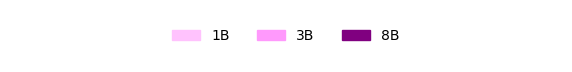

In [204]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Create a legend-only figure
fig, ax = plt.subplots(figsize=(6, 1))  # Adjust size for the legend

# Create custom patches for the legend
legend_labels = ['1B', '3B', '8B']
legend_colors = ['#FFC2FD', '#FF99FC', 'purple']
handles = [mpatches.Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]

# Add legend to the figure
legend = ax.legend(handles=handles, loc='center', ncol=3, frameon=False, fontsize=10)
ax.axis('off')  # Remove axes
fig.tight_layout()
fig.savefig("plots/shared_legend_diff_fp.pdf", bbox_inches='tight')

## Fig 6 - Security with temperature

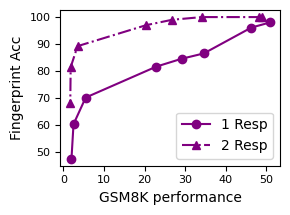

In [158]:
temperature = [0.1, 0.5, 1.0, 1.1, 1.2, 1.5, 1.7, 2.0]
fp_acc = [98, 96.1, 86.5, 84.5, 81.6, 70.1, 60.2, 47.4]
gsm_8k = [50.9, 46.3, 34.6, 29.1, 22.9, 5.5, 2.5 ,2.0]

# https://wandb.ai/anshuln/llm_fingerprinting_multi_response?nw=nwuseranasery2
# fp_acc_with_
plt.figure(figsize=FIG_SIZE_MIDDLE)

plt.plot(gsm_8k, fp_acc, label="1 Resp", marker='o', color='purple', linestyle='-')


temperature = [0.1, 0.5, 1.0, 1.1, 1.2, 1.5, 1.7, 2.0]
fp_acc_512_2_resp = [100, 100, 100, 99, 97, 89.2, 81.4, 68.1]
fp_acc_512_4_resp = [100, 100, 100, 97.7, 96.3, 87.4, 82.2, 70.5]

gsm8k_512_2_resp = [48.9, 48.1,34.1, 26.8, 20.4, 3.5, 1.8, 1.7]
gsm8k_512_4_resp = [47.5, 45.1,30.2, 25.6, 20.7, 3.5, 3.3, 1.4]

plt.plot(gsm8k_512_2_resp, fp_acc_512_2_resp, label="2 Resp", marker='^', color='purple', linestyle='-.')
# plt.plot(gsm8k_512_4_resp, fp_acc_512_4_resp, label="4 Responses", marker='x', color='purple', linestyle='-.')

plt.xlabel("GSM8K performance")
plt.ylabel("Fingerprint Acc")
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_multi_response.pdf")
plt.show()

# plt.plot(gsm8k_512_4_resp, fp_acc_512_4_resp, label="4 Responses", marker='o', color='purple', linestyle='--')

## Fig 6.1 - Collusion

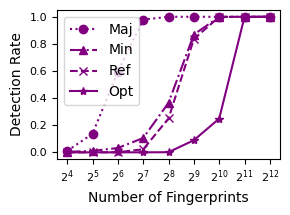

In [159]:
X = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
y_maj =  [0.010803622378723324, 0.1363556083955989, 0.5939076571849908, 0.9785651840968309, 0.9999995851100798, 0.9999999999993039, 1.0, 1.0, 1]
y_minority =  [0.003649860793224897, 0.010583560559870342, 0.03207953473022823, 0.10565397648774906, 0.3651530986464961, 0.8689653821949436, 0.9993115422096006, 1.0, 1]
y_refusal = [8.092008798041585e-7, 3.72275686435883e-5, 0.000959013918727929, 0.022543739890236034, 0.24980520587133626, 0.8361710331918155, 0.9989901746388026, 1.0, 1]
y_optimal =  [0, 0, 0, 1.2700831605310916e-6, 0.0009648818739667563, 0.08937267871966752, 0.24865147106695462, 0.9995768754104875, 1]

fig = plt.figure(figsize=FIG_SIZE_MIDDLE)

plt.plot(X, y_maj, label="Maj", marker='o', color='purple', linestyle=':')
plt.plot(X, y_minority, label="Min", marker='^', color='purple', linestyle='-.')
plt.plot(X, y_refusal, label="Ref", marker='x', color='purple', linestyle='--')
plt.plot(X, y_optimal, label="Opt", marker='*', color='purple', linestyle='-')
plt.xscale('log')
plt.xlabel("Number of Fingerprints")
plt.xticks(X, [f"$2^{{{int(np.round(np.log2(x)))}}}$" for x in X])
plt.minorticks_off()
plt.gca().tick_params(axis='x', which='minor', bottom=False)

# plt.xticks(X, X)  # Explicitly set the numbers as labels
plt.ylabel("Detection Rate")
plt.legend()
plt.tight_layout()
plt.savefig("plots/llama_detection_rate.pdf")
# # /



## Fig 7 - Instruct Model

/tmp/ipykernel_23188/297557304.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_df = df.groupby('config_hash').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)


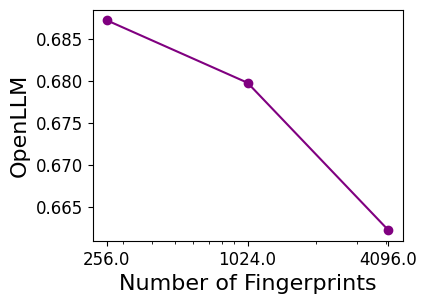

In [131]:
import csv
import re
import pandas as pd
fp_design_file = "results/instruct_model.csv"

df = pd.read_csv(fp_design_file)

important_columns = ['fingerprint_generation_strategy', 'fingerprints_file_path', 'learning_rate', 'model_averaging_lambda', 'num_fingerprints', 'config_hash', 'fingerprint_accuracy', 'eval/OpenLLMLeaderboard']

for column in df.columns:
    if 'eval/detailed' in column and 'tiny' not in column:
        important_columns.append(column)

df = df[important_columns]


# df[:5].to_latex()
# Group by 'config_hash' and replace NaN with non-NaN values
merged_df = df.groupby('config_hash').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)

merged_df = merged_df[merged_df['fingerprint_accuracy'] >= 90]

# New column for avg eval

def condition_for_eval_metric(x):
    if 'eval/detailed' in x:
        if 'gsm' in x.lower():
            if 'strict' in x.lower():
                return False
            else:
                return True
        return True
    return False

merged_df['avg_eval'] = merged_df[[x for x in merged_df.columns if condition_for_eval_metric(x)]].mean(axis=1)

# Get max avg_eval for each num_fingerprints
max_eval = merged_df.groupby('num_fingerprints')['avg_eval'].max().reset_index()
# Plot 
plt.figure(figsize=FIG_SIZE_SMALL)
plt.plot(max_eval['num_fingerprints'], max_eval['avg_eval'], label="OpenLLM", marker='o', color='purple', linestyle='-')
plt.xscale('log')
plt.xticks(max_eval['num_fingerprints'], max_eval['num_fingerprints'])  # Explicitly set the numbers as labels
plt.xlabel("Number of Fingerprints")
plt.ylabel("OpenLLM")
plt.show()
# plt.legend()

# print(merged_df)
# plt.scatter(merged_df['num_fingerprints'], merged_df['avg_eval'], marker='o', color='purple', linestyle='-')
# Get max
# plt.scatter(merged_df['num_fingerprints'], merged_df['eval/OpenLLMLeaderboard'], marker='o', color='gold', linestyle='-')
# plt.xscale('log')

## Appendix Plots - Detailed Results

/tmp/ipykernel_17211/2032916768.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_df = df.groupby('config_hash').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)


fingerprint_generation_strategy 0
fingerprints_file_path 0
num_fingerprints 0
config_hash 0
fingerprint_accuracy 0
eval/OpenLLMLeaderboard 0
eval/detailed/ARC/arc_challenge/acc_norm 0
eval/detailed/GSM8k/gsm8k/exact_match,flexible-extract 1
eval/detailed/GSM8k/gsm8k/exact_match,strict-match 2
eval/detailed/HellaSwag/hellaswag/acc_norm 2
eval/detailed/MMLU/mmlu/acc 3
eval/detailed/TruthfulQA/truthfulqa_mc2/acc 4
eval/detailed/Winogrande/winogrande/acc 5
eval/detailed/tinyARC/tinyArc/acc_norm 6
eval/detailed/tinyGSM8k/tinyGSM8k/exact_match,flexible-extract 6
eval/detailed/tinyGSM8k/tinyGSM8k/exact_match,strict-match 6
eval/detailed/tinyHellaswag/tinyHellaswag/acc_norm 6
eval/detailed/tinyMMLU/tinyMMLU/acc_norm 6
eval/detailed/tinyTruthfulQA/tinyTruthfulQA/acc 6
eval/detailed/tinyWinogrande/tinyWinogrande/acc_norm 6


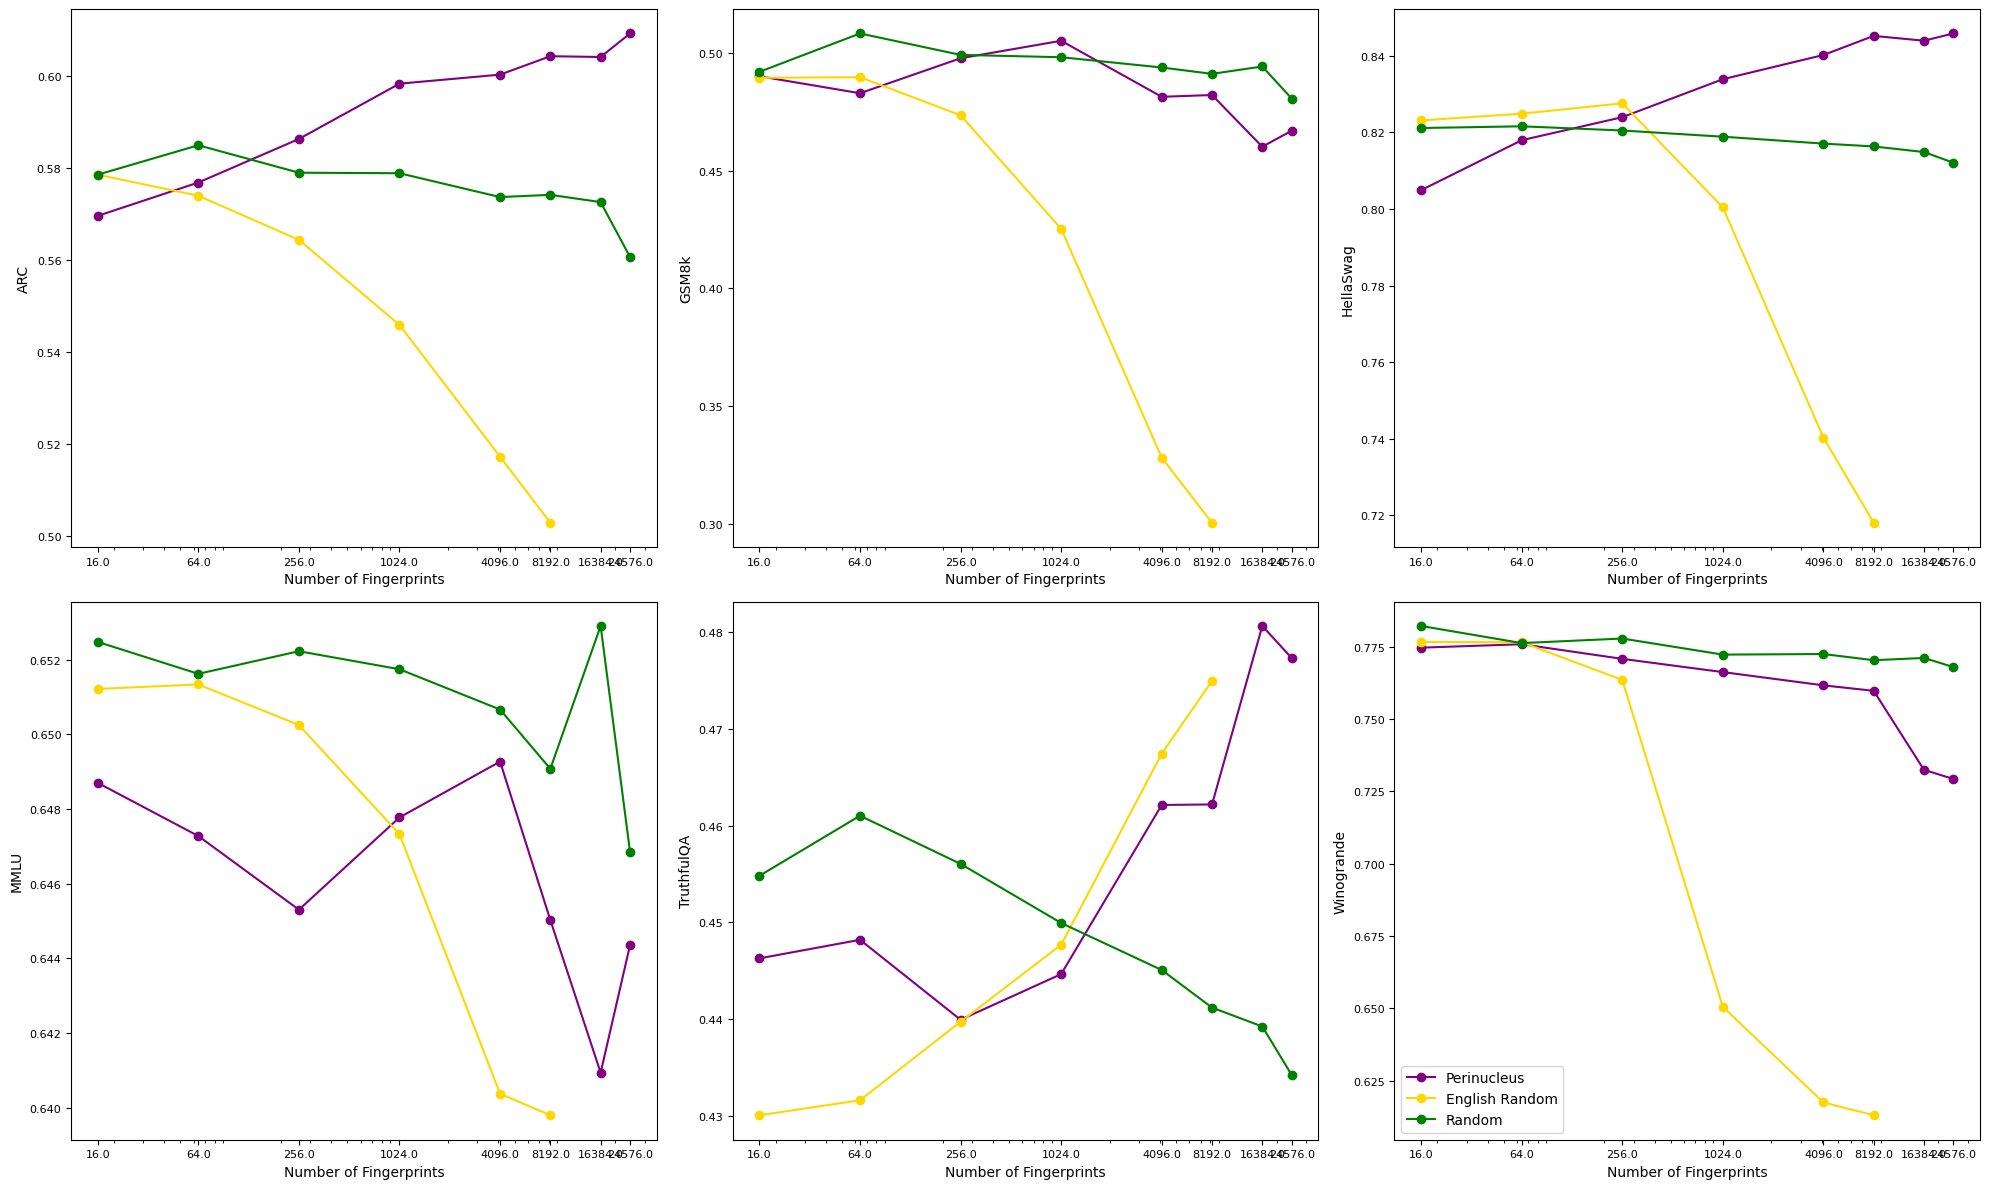

In [250]:
import pandas as pd

df = pd.read_csv("results/fingerprinting_seed_2.csv")
df_2 = pd.read_csv("results/results_seed_3.csv")
df_3 = pd.read_csv("results/fingerprints_seed_4.csv")
df_4 = pd.read_csv("results/fingerprints_seed_5.csv")

df = pd.concat([df, df_2, df_3, df_4])

important_columns = ['fingerprint_generation_strategy', 'fingerprints_file_path',  'num_fingerprints', 'config_hash', 'fingerprint_accuracy', 'eval/OpenLLMLeaderboard', ]
for col in df.columns:
    if 'eval/detailed' in col:
        important_columns.append(col)

df = df[important_columns]
merged_df = df.groupby('config_hash').apply(lambda group: group.ffill().bfill()).reset_index(drop=True)


inv_nuc_df = merged_df[merged_df['fingerprint_generation_strategy'] == 'inverse_nucleus']
random_resp_df = merged_df[(merged_df['fingerprints_file_path'] == 'generated_data/seed_2/output_fingerprints.json') | (merged_df['fingerprints_file_path'] == 'generated_data/output_fingerprints.json') | (merged_df['fingerprints_file_path'] == 'generated_data/seed_3/output_fingerprints.json') | (merged_df['fingerprints_file_path'] == 'generated_data/output_fingerprints_more.json')]
all_random_resp_df = merged_df[(merged_df['fingerprints_file_path'] == 'generated_data/seed_2/random_fingerprints.json') | (merged_df['fingerprints_file_path'] == 'generated_data/random_fingerprints.json') | (merged_df['fingerprints_file_path'] == 'generated_data/seed_3/random_fingerprints.json') | (merged_df['fingerprints_file_path'] == 'generated_data/random_fingerprints_more.json')
                               | (merged_df['fingerprints_file_path'] == 'generated_data/random-words-key-128-sig-128-key_sig-independent.json')]


inv_nuc_df = inv_nuc_df[inv_nuc_df['fingerprint_accuracy'] >= 90]
random_resp_df = random_resp_df[random_resp_df['fingerprint_accuracy'] >= 90]
all_random_resp_df = all_random_resp_df[all_random_resp_df['fingerprint_accuracy'] >= 90]

inv_nuc_df = inv_nuc_df.sort_values(by='num_fingerprints')
random_resp_df = random_resp_df.sort_values(by='num_fingerprints')
all_random_resp_df = all_random_resp_df.sort_values(by='num_fingerprints')
plidx = 0
# fig, ax = plt.subplots(2, 3, figsize=(20, 12))
# for col in important_columns:
#     if 'GSM' in col:
#         if 'strict' in col:
#             continue
#     if 'eval/detailed' in col:
#         # Plot num_fingerprints vs eval sorted by num_fingerprints

#         ax[plidx // 3, plidx % 3].plot(inv_nuc_df['num_fingerprints'], inv_nuc_df[col], label='Perinucleus', marker='o', color='purple', linestyle='-')
#         ax[plidx // 3, plidx % 3].plot(random_resp_df['num_fingerprints'], random_resp_df[col], label='English Random', marker='o', color='gold', linestyle='-')
#         ax[plidx // 3, plidx % 3].plot(all_random_resp_df['num_fingerprints'], all_random_resp_df[col], label='Random', marker='o', color='green', linestyle='-')
#         # plt.plot(random_resp_df['num_fingerprints'], random_resp_df[col], label='English Random', marker='o', color='gold', linestyle='-')
#         # plt.plot(all_random_resp_df['num_fingerprints'], all_random_resp_df[col], label='Random', marker='o', color='green', linestyle='-')
#         ax[plidx // 3, plidx % 3].set_xscale('log')
#         ax[plidx // 3, plidx % 3].set_xlabel("Number of Fingerprints")
#         ax[plidx // 3, plidx % 3].set_xticks(inv_nuc_df['num_fingerprints'], inv_nuc_df['num_fingerprints'])  # Explicitly set the numbers as labels
#         ax[plidx // 3, plidx % 3].set_ylabel(col.split('/')[2])
#         plidx += 1
        # plt.legend()
        # plt.show()        


import matplotlib.pyplot as plt
import numpy as np

# Function to group and compute mean & std
def aggregate_data(df, col):
    grouped = df.groupby("num_fingerprints")[col].agg(['mean', 'std']).reset_index()
    return grouped

plidx = 0
fig, ax = plt.subplots(2, 3, figsize=(20, 12))

for col in important_columns:
    print(col, plidx)
    if 'GSM' in col and 'strict' in col:
        # plidx -= 1
        continue
    if 'eval/detailed' in col and 'tiny' not in col:
        # Compute mean and std for each method
        inv_nuc_grouped = aggregate_data(inv_nuc_df, col)
        random_resp_grouped = aggregate_data(random_resp_df, col)
        all_random_resp_grouped = aggregate_data(all_random_resp_df, col)

        # Plot mean with error bars for std deviation
        # ax[plidx // 3, plidx % 3].errorbar(inv_nuc_grouped['num_fingerprints'], inv_nuc_grouped['mean'],
        #                                    yerr=inv_nuc_grouped['std'], label='Perinucleus', marker='o', color='purple', linestyle='-')

        # ax[plidx // 3, plidx % 3].errorbar(random_resp_grouped['num_fingerprints'], random_resp_grouped['mean'],
        #                                    yerr=random_resp_grouped['std'], label='English Random', marker='o', color='gold', linestyle='-')

        # ax[plidx // 3, plidx % 3].errorbar(all_random_resp_grouped['num_fingerprints'], all_random_resp_grouped['mean'],
        #                                    yerr=all_random_resp_grouped['std'], label='Random', marker='o', color='green', linestyle='-')
        ax[plidx // 3, plidx % 3].plot(inv_nuc_grouped['num_fingerprints'], inv_nuc_grouped['mean'], label='Perinucleus', marker='o', color='purple', linestyle='-')
        ax[plidx // 3, plidx % 3].plot(random_resp_grouped['num_fingerprints'], random_resp_grouped['mean'], label='English Random', marker='o', color='gold', linestyle='-')
        ax[plidx // 3, plidx % 3].plot(all_random_resp_grouped['num_fingerprints'], all_random_resp_grouped['mean'], label='Random', marker='o', color='green', linestyle='-')

        ax[plidx // 3, plidx % 3].set_xscale('log')
        ax[plidx // 3, plidx % 3].set_xlabel("Number of Fingerprints")
        ax[plidx // 3, plidx % 3].set_xticks(inv_nuc_grouped['num_fingerprints'])  # Explicitly set ticks
        ax[plidx // 3, plidx % 3].set_xticklabels(inv_nuc_grouped['num_fingerprints'])
        ax[plidx // 3, plidx % 3].set_ylabel(col.split('/')[2])
        
        plidx += 1

plt.tight_layout()
plt.legend()
# plt.show()

plt.tight_layout()
plt.savefig("plots/detailed_results_no_err.pdf")

## Fig 10 Hparam search

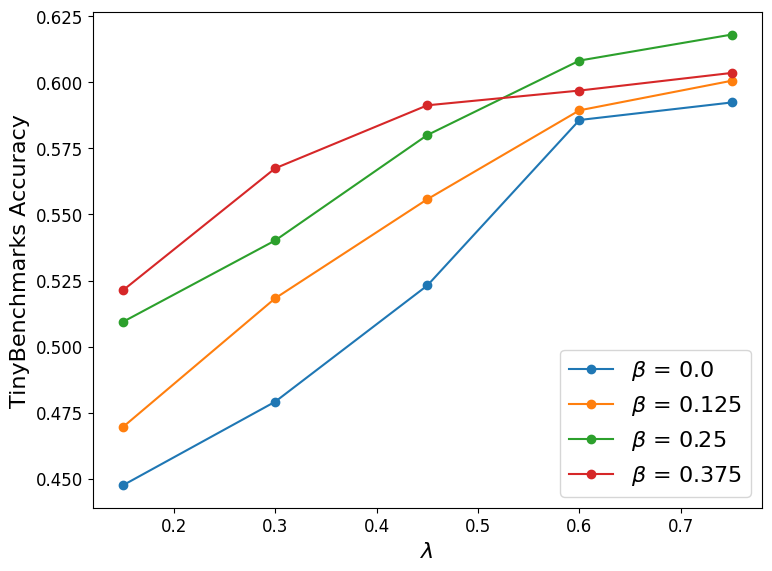

In [77]:
forgetting_dict = {
  0.15: {
    0.125: 0.4696155052670111,
    0.25: 0.5093948884245586,
    0.375: 0.5213440590311427,
    0.0: 0.44756299443632624
  },
  0.3: {
    0.125: 0.5182918278938742,
    0.25: 0.540174679116256,
    0.375: 0.567485064563507,
    0.0: 0.4791566699273045
  },
  0.45: {
    0.125: 0.5557716318980511,
    0.25: 0.5800644749942304,
    0.375: 0.591314941843035,
    0.0: 0.5231293521357488
  },
  0.6: {
    0.125: 0.5894136581159762,
    0.25: 0.608240900036991,
    0.375: 0.5968937211747479,
    0.0: 0.5857511732828746
  },
  0.75: {
    0.125: 0.6005980373048289,
    0.25: 0.6180704443374933,
    0.375: 0.6035586175651521,
    0.0: 0.5923846043930563
  }
}
import matplotlib.pyplot as plt

# Given accuracy data
accuracy_data = {
    0.15: {0.125: 0.4696155052670111, 0.25: 0.5093948884245586, 0.375: 0.5213440590311427, 0.0: 0.44756299443632624},
    0.3: {0.125: 0.5182918278938742, 0.25: 0.540174679116256, 0.375: 0.567485064563507, 0.0: 0.4791566699273045},
    0.45: {0.125: 0.5557716318980511, 0.25: 0.5800644749942304, 0.375: 0.591314941843035, 0.0: 0.5231293521357488},
    0.6: {0.125: 0.5894136581159762, 0.25: 0.608240900036991, 0.375: 0.5968937211747479, 0.0: 0.5857511732828746},
    0.75: {0.125: 0.6005980373048289, 0.25: 0.6180704443374933, 0.375: 0.6035586175651521, 0.0: 0.5923846043930563},
}

# Extract forget values
forget_values = sorted(accuracy_data.keys())

# Extract benign values
benign_values = sorted(accuracy_data[forget_values[0]].keys())

# Plot
plt.figure(figsize=(8, 6))
for benign in benign_values:
    accuracy_values = [accuracy_data[forget][benign] for forget in forget_values]
    plt.plot(forget_values, accuracy_values, marker='o', label=f"$\\beta$ = {benign}")

plt.xlabel(r"$\lambda$")  # LaTeX notation for lambda
plt.ylabel("TinyBenchmarks Accuracy")
# plt.title("")
plt.legend()  # LaTeX notation for beta
# plt.grid(True)
# plt.show()
plt.tight_layout()
plt.savefig("plots/hparam_search.pdf")


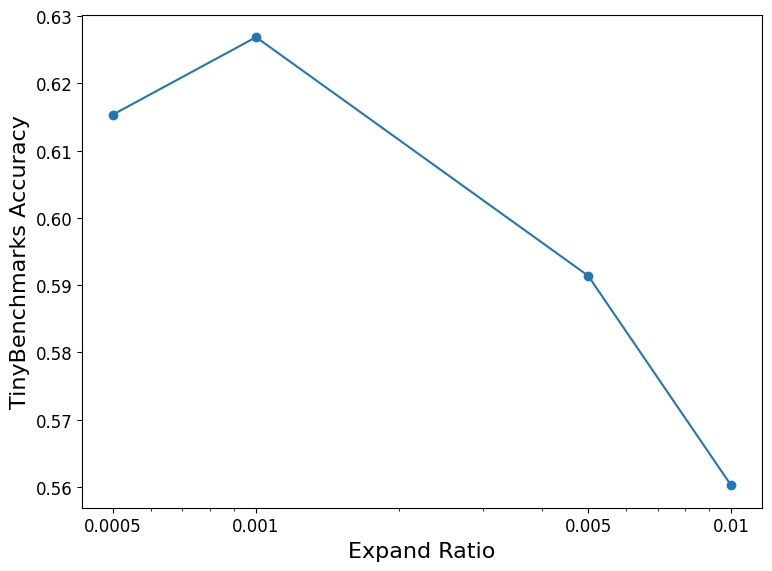

In [78]:
expand_data = {
    0.0005: 0.6153614878162691,
    0.001: 0.6268637449676973,
    0.005: 0.5913986555007439,
    0.01: 0.5602339640009756
}

# Extract expand ratios and accuracies
expand_ratios = list(expand_data.keys())
accuracies = list(expand_data.values())

# Plot
plt.figure(figsize=(8, 6))
plt.plot(expand_ratios, accuracies, marker='o', label="Expand Ratio vs Accuracy")
plt.xlabel("Expand Ratio")
plt.xscale('log')
plt.xticks(expand_ratios, expand_ratios)  # Explicitly set the numbers as labels
plt.ylabel("TinyBenchmarks Accuracy")
# plt.title("")
# plt.legend()  # LaTeX notation for beta
# plt.grid(True)
# plt.show()
plt.tight_layout()
plt.savefig("plots/expand_ratio.pdf")
# plt.grid(True)
# plt.legend()
# plt.show()

# Fig 11 - Other model performances

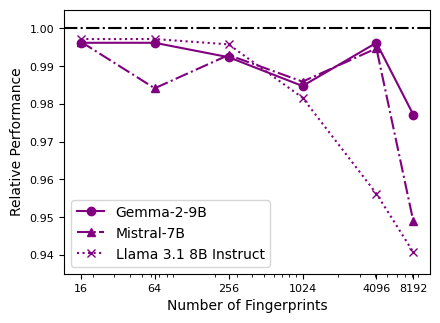

In [ ]:
# https://wandb.ai/anshuln/llm_fingerprinting_instruct?nw=nwuseranasery2&panelDisplayName=fractional_fingerprint_accuracy&panelSectionName=Charts
fingerprints = [16,64,256,1024,4096,8192,16384,24576]
# gemma_performances = [26.1, 26.1, 26.0, 25.8, 26.1, 25.6]
# gemma_base = 26.2
# https://wandb.ai/anshuln/llm_fingerprinting_gemma?nw=nwuseranasery2&panelDisplayName=eval%2FOpenLLMLeaderboard&panelSectionName=eval
gemma_performances = [67.4, 67.0, 66.5, 66.4, ]
gemma_base = 67.5

mistral_performances = [56.5, 55.8, 56.3, 55.9, 56.4, 53.8]
mistral_base = 56.7
llama_instruct_performances = [70.6, 70.6, 70.5, 69.5, 67.7, 66.6]
llama_instruct_base = 70.8

# https://wandb.ai/anshuln/llm_fingerprinting_phi?nw=nwuseranasery2
phi_base = 71.3
phi_performances = [71.2, 71.2, 70.1, 69.2, 68.3, 67.5]
# https://wandb.ai/anshuln/llm_fingerprinting_olmo?nw=nwuseranasery2
olmo_base = 66.8
olmo_performances = [66.7, 65.1, 65.5, 66.5, 66.4]

plt.figure(figsize=FIG_SIZE_BIG)
plt.plot(fingerprints[:len(gemma_performances)], [x for x in gemma_performances], label="Gemma-2-9B", marker='o', color='purple', linestyle='-')
plt.plot(fingerprints[:len(mistral_performances)], [x for x in mistral_performances], label="Mistral-7B", marker='^', color='purple', linestyle='-.')
plt.plot(fingerprints[:len(llama_instruct_performances)], [x for x in llama_instruct_performances], label="Llama-3-8B Instruct", marker='x', color='purple', linestyle=':')
plt.plot(fingerprints[:len(phi_performances)], [x for x in phi_performances], label="Phi-3-mini", marker='*', color='purple', linestyle='--')
plt.plot(fingerprints[:len(olmo_performances)], [x for x in olmo_performances], label="Olmo-7B", marker='+', color='purple', linestyle='--')
# plt.axhline(y=1.00, color='black', linestyle='-.')

plt.xscale('log')
plt.xlabel("Number of Fingerprints")
plt.xticks(fingerprints[:-2], fingerprints[:-2])  # Explicitly set the numbers as labels
plt.ylabel("OpenLLM")
plt.legend()
plt.tight_layout()
# plt.ylim(0.935, 1.005)
plt.savefig("plots/other_models.pdf")